Customer Lifetime Value Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn



In [2]:
import sys
print(sys.executable)

/Users/helensoremekun/Desktop/deployed_CLV/.venv/bin/python


In [3]:
df = pd.read_csv('/Users/helensoremekun/Desktop/deployed_CLV/customer_segmentation.csv', encoding='ISO-8859-1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# Data Exploration and Cleaning

In [6]:
#checking the data types 
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [7]:
#Checking if there is any null values
df.isnull().values.any() 

np.True_

In [8]:
#checks for missing values in columns
df.isna().sum() # 24.9% of the customer id  is missing and a 1454 records of description, 
#the description is inconsequential but a decision has to be made concerning missing customer id

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# dropping rows with missing customer_id
df = df[df['CustomerID'].notna()] #CustomerID is important for CLV prediction

df.shape

(406829, 8)

In [10]:
#Changing customer_id to string.. object data type
df['CustomerID'] = df['CustomerID'].round().astype(int)
df['CustomerID'] = df['CustomerID'].astype(str)


#converting invoice date to date time datatype, customer_id from float to string
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors= "coerce")
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
dtype: object

In [11]:
#Checking for any NaT values
df['InvoiceDate'].isnull().values.any()  # OR df['InvoiceDate'].isna().sum() > 0


np.False_

In [12]:
#counting number of unique countries
df['Country'].nunique()

37

In [13]:
#checking countries 
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Saudi Arabia', 'Czech Republic', 'Canada',
       'Unspecified', 'Brazil', 'USA', 'European Community', 'Bahrain',
       'Malta', 'RSA'], dtype=object)

In [14]:
#obtaining records of unspecified countries
df[df['Country'] == 'Unspecified']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
152712,549687,20685,DOORMAT RED RETROSPOT,2,2011-04-11 13:29:00,7.95,12363,Unspecified
152713,549687,22691,DOORMAT WELCOME SUNRISE,2,2011-04-11 13:29:00,7.95,12363,Unspecified
152714,549687,48116,DOORMAT MULTICOLOUR STRIPE,2,2011-04-11 13:29:00,7.95,12363,Unspecified
152715,549687,21213,PACK OF 72 SKULL CAKE CASES,24,2011-04-11 13:29:00,0.55,12363,Unspecified
152716,549687,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24,2011-04-11 13:29:00,0.55,12363,Unspecified
...,...,...,...,...,...,...,...,...
308810,564051,23007,SPACEBOY BABY GIFT SET,1,2011-08-22 13:32:00,16.95,14265,Unspecified
308811,564051,21833,CAMOUFLAGE LED TORCH,12,2011-08-22 13:32:00,1.69,14265,Unspecified
308812,564051,23081,GREEN METAL BOX ARMY SUPPLIES,2,2011-08-22 13:32:00,8.25,14265,Unspecified
308813,564051,23046,PAPER LANTERN 9 POINT DELUXE STAR,2,2011-08-22 13:32:00,6.65,14265,Unspecified


## Handling missing values

In [15]:
#checking for any missing value
df.isnull().values.any()

np.False_

In [16]:
#checking if there exists the same invoice number for different country
unique_group =  df[['InvoiceNo','Country']].drop_duplicates()
duplicates  = unique_group['InvoiceNo'].duplicated().sum()
duplicates

np.int64(0)

In [17]:
#counting the unique countries for each Invoice No
invoice_country_count = df.groupby('InvoiceNo')[['Country', 'InvoiceDate']].nunique()

#finding invoices that are related to more than one country
duplicate_invoice =  invoice_country_count[invoice_country_count['Country']>1]
print(f"Number of Invoice No appearing in multiple countries are: {len(duplicate_invoice)}")

#finding invoices that are related to more than one date
duplicate_invoice =  invoice_country_count[invoice_country_count['InvoiceDate']>1]
print(f"Number of Invoice No appearing in multiple InvoiceDates are: {len(duplicate_invoice)}")

Number of Invoice No appearing in multiple countries are: 0
Number of Invoice No appearing in multiple InvoiceDates are: 31


Observation: Based on the above observation
The invoices are unique to each countries

In [18]:
#checking how many countries that a customer id appears
customer_country_count = df.groupby('CustomerID')['Country'].nunique()
customer_country_duplicates = customer_country_count[customer_country_count>1]
print(f"Most customer order from the same country except : {len(customer_country_duplicates)}")

Most customer order from the same country except : 8


Task: Filling "unspecified country" with most common country because it was observed that all customers with missing countries have their country name missing for all transactions.most commom country is "United Kingdom"

In [19]:
#Filling "unspecified country" with most common country"
customer_country_map = df["Country"].agg(lambda x: x.mode()[0]) #customer_country_map = df["Country"].agg(lambda x: x.mode()[0]if not x.isnull().all() else None)

#Now fill with missing country with the most frequent country for the customers
df['Country'] = df['Country'].replace("Unspecified", np.nan)
df['Country']= df['Country'].fillna(customer_country_map)

In [20]:
df[df['Country']== 'Unspecified'] # confirmed that all unspecified country has been filled

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [21]:
#Missing values in columns
df.isna().sum() 

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [22]:
#checking for any duplicated rows
df.duplicated().values.any()

np.True_

In [23]:
#checks for duplicate
df.duplicated(keep= 'first').sum()

np.int64(5225)

In [24]:
new_duplicate = df[df.duplicated(
    subset=["InvoiceNo", "StockCode", "CustomerID", "InvoiceDate"], keep = False
)]
new_duplicate

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
113,536381,71270,PHOTO CLIP LINE,1,2010-12-01 09:41:00,1.25,15311,United Kingdom
125,536381,71270,PHOTO CLIP LINE,3,2010-12-01 09:41:00,1.25,15311,United Kingdom
483,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,3,2010-12-01 11:45:00,6.35,17908,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
...,...,...,...,...,...,...,...,...
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446,United Kingdom
541697,581538,21194,PINK HONEYCOMB PAPER FAN,1,2011-12-09 11:34:00,0.65,14446,United Kingdom
541698,581538,35004B,SET OF 3 BLACK FLYING DUCKS,1,2011-12-09 11:34:00,5.45,14446,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446,United Kingdom


In [25]:
df[df.duplicated(keep=False)].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920,United Kingdom


Observation: Duplicated transactions are not dropped as they are assumed to be multiple transaction of the same order by the same customer in the same time.

## Checks for outliers

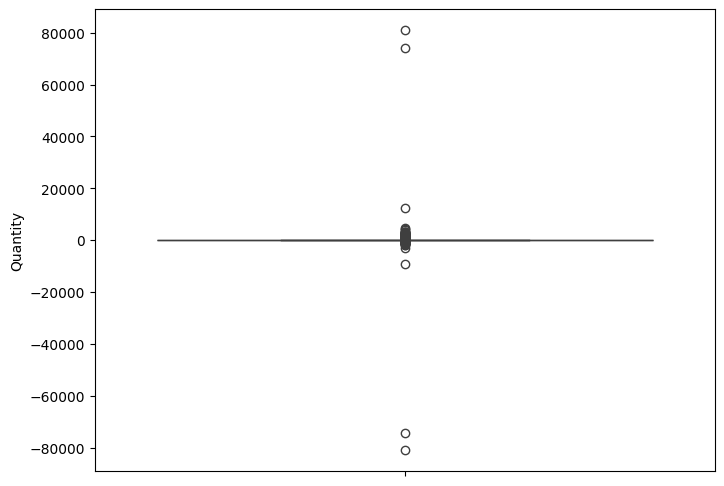

In [26]:
#Visualizing outliers with boxplot for numeric column field Quantity and UnitPrice
plt.figure(figsize = (8,6))


sns.boxplot(df["Quantity"])


plt.show()

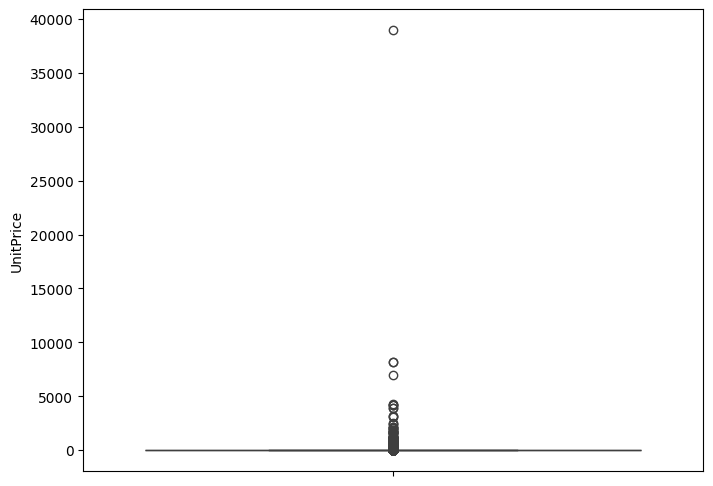

In [27]:
plt.figure(figsize = (8,6))

sns.boxplot(df["UnitPrice"])


plt.show()

In [28]:
#Using zscore to see how far each data point is from the mean for Quantity and Unit Price
from scipy import stats

quantity_z_score = np.abs(stats.zscore(df["Quantity"]))
unitPrice_z_score = np.abs(stats.zscore(df["UnitPrice"]))
print(f"z_score for {df.columns[3]} is: {quantity_z_score}")
print(f"z_score for {df.columns[4]} is: {unitPrice_z_score}")


z_score for Quantity is: [0.02437263 0.02437263 0.01633059 ... 0.03241467 0.03241467 0.03643569]
z_score for InvoiceDate is: [0.01313525 0.00101668 0.01024988 ... 0.00994775 0.00994775 0.02148925]


In [29]:
#Removal of outliers, using a threshold 3, where zvalue is greater than 3
z_threshold = 3

quantity_outliers = np.where((quantity_z_score > z_threshold) | (quantity_z_score < -z_threshold))[0]
unitPrice_outliers = np.where((unitPrice_z_score > z_threshold) | (unitPrice_z_score < -z_threshold))[0]

outlier_indices = np.union1d(quantity_outliers, unitPrice_outliers)

no_outliers_df =  df.drop(index = df.index[outlier_indices])
print("Original dataframe shape: ", df.shape)
print("Dataframe after removing outliers", no_outliers_df.shape)

Original dataframe shape:  (406829, 8)
Dataframe after removing outliers (406492, 8)


In [30]:
#Assigning no_outliers_df as the dataframe to work with 
df = no_outliers_df
df.shape

(406492, 8)

In [31]:
#Checking for negative quantity value

df[df["Quantity"]< 0].head(25)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897,United Kingdom


In [32]:
#shape of data setafter dropping negative quantities
df.shape

(406492, 8)

Assumption:
Dropping rows with negative quantity with the assumption they are returned items

In [33]:
#dropping rows with negative quantity with the assumption they are returned items
df = df[df["Quantity"]>0]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


# Descriptive Statistics and Exploratory Data Analysis (EDA)

Assumption:
assumptions  were  made that  duplicated transactions with all columns the same were transactions of products made twice at the same time by same customers, and leaving them as they are.

In [34]:
df.describe(include='number')

,Quantity,UnitPrice
count,397679.000000,397679.000000
mean,12.029064,2.930690
std,29.664228,4.106585
min,1.000000,0.000000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,756.000000,208.340000


In [35]:
df.describe(include='object')

,InvoiceNo,StockCode,Description,CustomerID,Country
count,397679,397679,397679,397679,397679
unique,18440,3663,3874,4326,36
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17841,United Kingdom
freq,541,2031,2024,7847,354393


In [36]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [37]:
df['CustomerID'].nunique()

4326

In [38]:
#obtaining distribution of customers across countries
cust_perCountry = df.groupby('Country')['CustomerID'].nunique().reset_index(name='Count')
cust_perCountry['percentage'] = round(cust_perCountry['Count']/cust_perCountry['Count'].sum() *100, 2)
cust_perCountry.sort_values(by='percentage', ascending=False).reset_index(drop=True).set_axis(range(1, len(cust_perCountry)+1))

,Country,Count,percentage
1,United Kingdom,3912,90.26
2,Germany,94,2.17
3,France,87,2.01
4,Spain,30,0.69
5,Belgium,25,0.58
6,Switzerland,21,0.48
7,Portugal,19,0.44
8,Italy,14,0.32
9,Finland,12,0.28
10,Austria,11,0.25


In [39]:
#obtaining top 10 values
top10_cust_perCountry = cust_perCountry.sort_values(by='percentage', ascending=False).reset_index(drop=True).head(10)
top10_cust_perCountry

,Country,Count,percentage
0,United Kingdom,3912,90.26
1,Germany,94,2.17
2,France,87,2.01
3,Spain,30,0.69
4,Belgium,25,0.58
5,Switzerland,21,0.48
6,Portugal,19,0.44
7,Italy,14,0.32
8,Finland,12,0.28
9,Austria,11,0.25


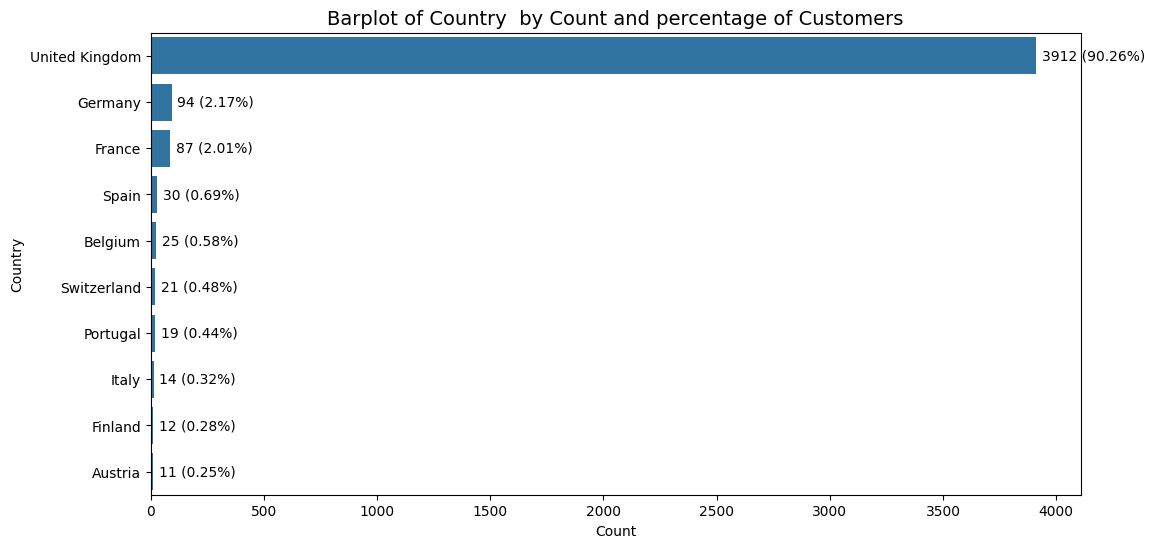

In [40]:
#plot of "Barplot of Country  against Count and percentage of Customers"

plt.figure(figsize=(12,6))
ax = sns.barplot(top10_cust_perCountry, x = 'Count', y= 'Country')

ax.set_title("Barplot of Country  by Count and percentage of Customers", fontsize =14)

labels = [f"{count} ({percent}%)" for count, percent in zip(top10_cust_perCountry['Count'], top10_cust_perCountry['percentage'])]

ax.bar_label(ax.containers[0], labels= labels, fontsize=10, padding =4)

plt.show()

In [41]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [42]:
# Checks to see relationship between stockcodes and description 
print("the no of unique stock codes are: ", df['StockCode'].nunique())
print("the no of unique descriptions are: ", df['Description'].nunique())

#obtaining unique pairs
unique_pairs = df[['StockCode','Description']].drop_duplicates()
unique_pairs

duplicate_count = unique_pairs['StockCode'].duplicated().sum()
if duplicate_count ==0:
    print("Each stockcode has a unique 'descriptions'" "(One-to-One relationship)")
else:
    print(f"{duplicate_count} 'stockcodes' has multple descriptions ")


the no of unique stock codes are:  3663
the no of unique descriptions are:  3874
231 'stockcodes' has multple descriptions 


In [43]:
#Dropping description column as it is not instrumental to our analysis
df = df.drop(columns='Description')
df.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [44]:
top10_stocks_byFreq = df['StockCode'].value_counts()\
                                    .reset_index(name='Frequency')\
                                    .sort_values(by ='Frequency', ascending=False).head(10)
top10_stocks_byFreq

,StockCode,Frequency
0,85123A,2031
1,22423,1724
2,85099B,1615
3,84879,1405
4,47566,1397
5,20725,1317
6,22720,1159
7,20727,1105
8,23203,1098
9,POST,1091


In [45]:
top10_stocks_byFreq['Frequency'].mean()

np.float64(1394.2)

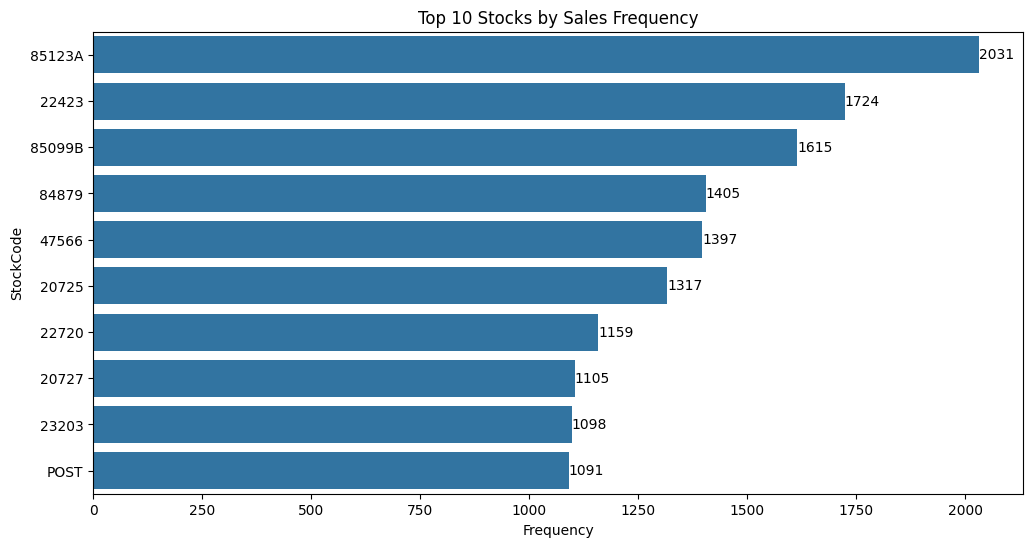

In [46]:
#Obtaining top 10 sales frequency using stockcode as unique identifier of products

plt.figure(figsize=(12,6))

ax =sns.barplot(top10_stocks_byFreq, y = "StockCode", x= "Frequency")
ax.bar_label(ax.containers[0], labels = top10_stocks_byFreq["Frequency"], fontsize =10)
ax.set_title("Top 10 Stocks by Sales Frequency")

plt.show()

In [47]:
df.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


#group by customer and transaction volume.
#group by customer and quantity of purchase
#group by monetary value and quarterly from 2010 to 2011

In [48]:
#creating new columns to depict Total Sales 
df['TotalSales'] = df['UnitPrice'].mul(df['Quantity'])


In [49]:
df.dtypes

InvoiceNo              object
StockCode              object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
TotalSales            float64
dtype: object

In [50]:
#Group by customer and transaction volume including Guests (customers with unknown id)
cust_ByTrans = df.groupby("CustomerID")['TotalSales'].sum().reset_index(name="TotalRevenue")
cust_ByTrans

,CustomerID,TotalRevenue
0,12347,4310.00
1,12348,1797.24
2,12349,1457.55
3,12350,334.40
4,12352,1849.49
...,...,...
4321,18280,180.60
4322,18281,80.82
4323,18282,178.05
4324,18283,2094.88


In [51]:
cust_ByTrans= cust_ByTrans.sort_values(by = "TotalRevenue", ascending=False).head(20)
cust_ByTrans

,CustomerID,TotalRevenue
1686,14646,268891.46
4190,18102,250509.70
3719,17450,152206.35
1876,14911,140450.72
54,12415,122212.53
1330,14156,116746.03
3762,17511,91062.38
3169,16684,66381.56
993,13694,64640.74
2696,16029,62148.81


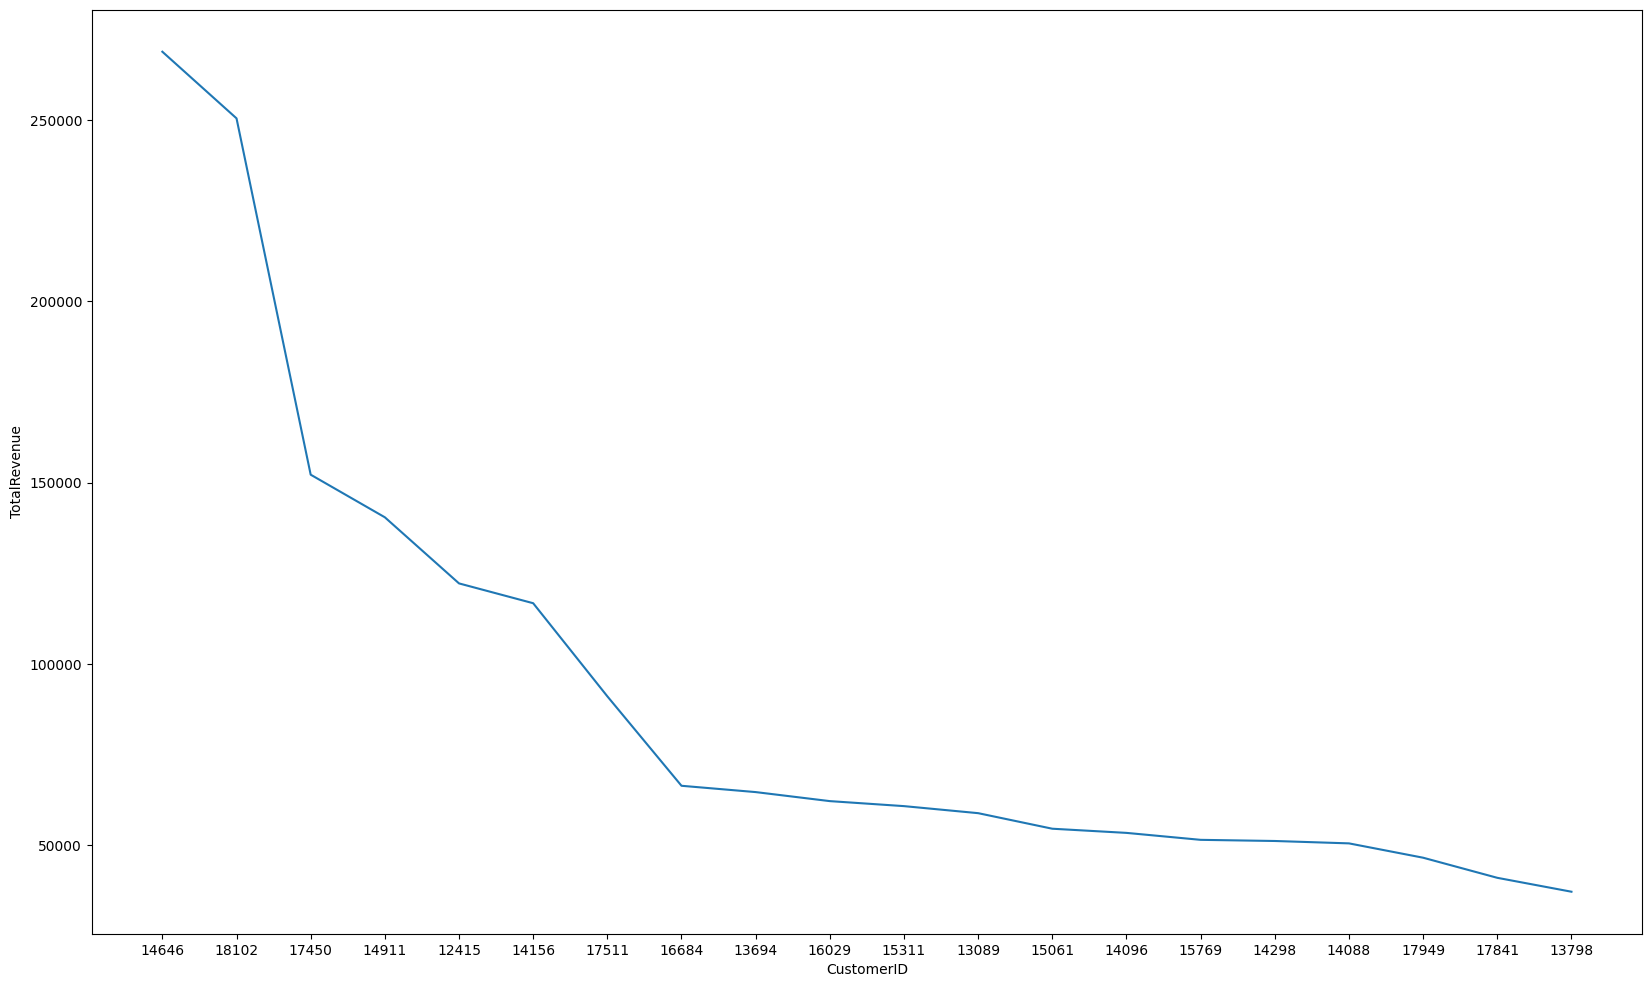

In [52]:
#obtaining the top 20 highest revenue generating customers
plt.figure(figsize=(20, 12))
sns.lineplot(data =cust_ByTrans, x="CustomerID" , y = "TotalRevenue")
plt.show()

In [53]:
#Obtaining frequency of purchase by customers quarterly

df['YearQuarter'] =  df["InvoiceDate"].dt.to_period('Q')

Purchase_quarter = df.groupby(["CustomerID", "YearQuarter"]).size().reset_index(name = "Purchase_Count_PerQ")
Purchase_quarter

,CustomerID,YearQuarter,Purchase_Count_PerQ
0,12347,2010Q4,31
1,12347,2011Q1,29
2,12347,2011Q2,42
3,12347,2011Q3,22
4,12347,2011Q4,58
...,...,...,...
9340,18283,2011Q2,211
9341,18283,2011Q3,104
9342,18283,2011Q4,309
9343,18287,2011Q2,29


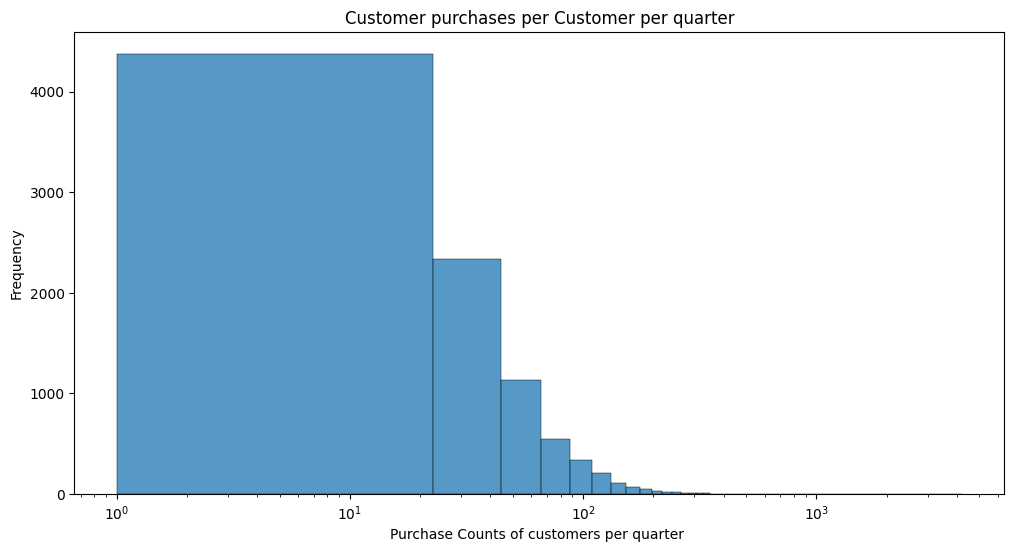

In [54]:
#obtaining distribution of frequency of purchase by customers quarterly
plt.figure(figsize= (12, 6))

sns.histplot(Purchase_quarter["Purchase_Count_PerQ"])#, bins = "auto" , kde=True)
plt.title("Customer purchases per Customer per quarter")
plt.xlabel("Purchase Counts of customers per quarter ")
plt.xscale('log')
plt.ylabel("Frequency")
plt.show()


In [55]:
#obtaining seasonal trend per quarter 
freq_trend  = Purchase_quarter.groupby("YearQuarter")['Purchase_Count_PerQ'].sum().reset_index()
freq_trend

,YearQuarter,Purchase_Count_PerQ
0,2010Q4,26143
1,2011Q1,68290
2,2011Q2,78089
3,2011Q3,93827
4,2011Q4,131330


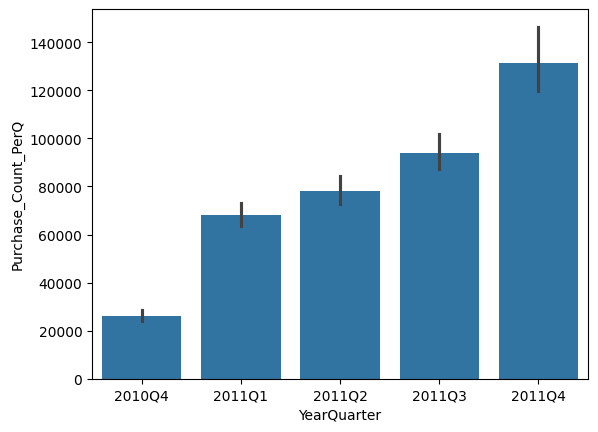

In [56]:
#Highlighting total purchase per quarter.
sns.barplot(x="YearQuarter", y = "Purchase_Count_PerQ", data =Purchase_quarter, estimator=sum)
plt.show()

Observation:
Purcahse frequency increased from 2010 Quarter 4 to 2011 Quarter 4.

In [57]:
df.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,YearQuarter
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010Q4
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010Q4
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010Q4
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010Q4
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010Q4


In [58]:
Transaction_df =  df[["YearQuarter", "TotalSales"]]
Transaction_df

,YearQuarter,TotalSales
0,2010Q4,15.30
1,2010Q4,20.34
2,2010Q4,22.00
3,2010Q4,20.34
4,2010Q4,20.34
...,...,...
541904,2011Q4,10.20
541905,2011Q4,12.60
541906,2011Q4,16.60
541907,2011Q4,16.60


In [59]:
#Table sum of sales of finanacial transactions quarterly over the 2 years 2010-2011
Transaction_freq =  df.groupby("YearQuarter")["TotalSales"].sum().reset_index()
Transaction_freq

,YearQuarter,TotalSales
0,2010Q4,551601.430
1,2011Q1,1478047.990
2,2011Q2,1702161.191
3,2011Q3,2149609.003
4,2011Q4,2452268.810


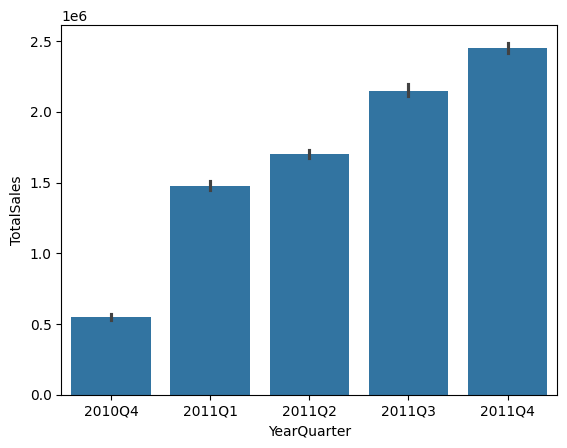

In [60]:
#obtaining distribution of finanacial transactions quarterly over the 2 years 2010-2011
sns.barplot(data = Transaction_df, x= "YearQuarter", y= "TotalSales", estimator=sum)
plt.show()

# Feature Engineering


setting a cut-off date to use as 2011-06-30 00:00:00 30th of June, 2011  as cut-off date
Obtaining the following values: 

* Recency: How long it's been since a customer's last purchase from the cut-off date. if recency is high, it means customer has not interacted with brand or company in a long while from the cut-off date.
* Frequency: How many times a customer has purchased within a specific given time frame. Given period use in the data set is between overall first date of purchase to the cut-off date.  
* Monetary: How much a customer has spent on a product or service within the same specific given time frame. Given period use in the data set is between overall first date of purchase to the cut-off date.  

In [61]:
df.head(2)

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,YearQuarter
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010Q4
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010Q4


In [62]:
#setting a cut-off date to use as 2011-06-30 00:00:00 30th of June, 2011  as cut-off date
# Now recency is  how long its been a customer's last purchase from the cut-off date 


cut_off_date =  pd.to_datetime('2011-06-30 00:00:00')  # As date before the last months 
last_date =  cut_off_date
first_date = pd.to_datetime('2011-03-01 00:00:00') # As the first date of the training set window
print(f"The {first_date} is the first date of purchase")
print(f"The {last_date} is the last cut-off date of purchase")

The 2011-03-01 00:00:00 is the first date of purchase
The 2011-06-30 00:00:00 is the last cut-off date of purchase


In [63]:
df['InvoiceDate'].min()

Timestamp('2010-12-01 08:26:00')

In [64]:
df['YearQuarter'].unique() 

<PeriodArray>
['2010Q4', '2011Q1', '2011Q2', '2011Q3', '2011Q4']
Length: 5, dtype: period[Q-DEC]

Observation: Based on the above, first date of purchase is 1st of March, 2011, and last date of purchase is 9th December, 2011. 
We start our dataset from the first of march 2011, instead of from december because of our assumption 
Assumption made: Customers are  new from the first months, and data records are for existing customers from the 4th month march.

Obtaining our data set for training  and testing set

In [65]:
# Obtaining data from before the cut_off_date
full_df = df[(df['InvoiceDate']<= cut_off_date) & (df['InvoiceDate'] >= first_date)] # slicing dataframe to obtain data before the cut-off date and our first date 
full_df['YearQuarter'].unique() # we obtain data from after our chosen first date and our last date

<PeriodArray>
['2011Q1', '2011Q2']
Length: 2, dtype: period[Q-DEC]

In [66]:
new_duplicate_full = full_df[full_df.duplicated(
    subset=["InvoiceNo", "StockCode", "CustomerID", "InvoiceDate"], keep = False
)]
new_duplicate_full

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,YearQuarter
105756,545276,84952C,6,2011-03-01 11:30:00,3.75,12933,United Kingdom,22.50,2011Q1
105759,545276,84952C,2,2011-03-01 11:30:00,3.75,12933,United Kingdom,7.50,2011Q1
105848,545290,77101A,1,2011-03-01 12:01:00,1.25,14688,United Kingdom,1.25,2011Q1
105850,545290,77101A,1,2011-03-01 12:01:00,1.25,14688,United Kingdom,1.25,2011Q1
106113,545312,44234,3,2011-03-01 13:51:00,0.21,15456,United Kingdom,0.63,2011Q1
...,...,...,...,...,...,...,...,...,...
243433,558459,22355,3,2011-06-29 14:20:00,0.85,15334,United Kingdom,2.55,2011Q2
243455,558461,23308,2,2011-06-29 15:03:00,0.55,13263,United Kingdom,1.10,2011Q2
243473,558461,23308,1,2011-06-29 15:03:00,0.55,13263,United Kingdom,0.55,2011Q2
243532,558467,23196,2,2011-06-29 15:22:00,1.45,17757,United Kingdom,2.90,2011Q2


In [67]:
full_df[full_df['CustomerID']=='13225']

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,YearQuarter
118637,546464,85099B,100,2011-03-14 10:57:00,1.65,13225,United Kingdom,165.00,2011Q1
118638,546464,82483,64,2011-03-14 10:57:00,5.95,13225,United Kingdom,380.80,2011Q1
118639,546464,21181,48,2011-03-14 10:57:00,1.85,13225,United Kingdom,88.80,2011Q1
118640,546464,21175,48,2011-03-14 10:57:00,2.08,13225,United Kingdom,99.84,2011Q1
206248,554919,21929,100,2011-05-27 12:38:00,1.79,13225,United Kingdom,179.00,2011Q2
206249,554919,22386,100,2011-05-27 12:38:00,1.79,13225,United Kingdom,179.00,2011Q2
206250,554919,85099C,100,2011-05-27 12:38:00,1.79,13225,United Kingdom,179.00,2011Q2


In [68]:
export_data =  full_df.reset_index(names='id').drop(index=1)
export_data
export_data.to_csv('./clv_sql_data.csv', index=False)

In [69]:
full_df.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,YearQuarter
105335,545220,21955,2,2011-03-01 08:30:00,7.95,14620,United Kingdom,15.90,2011Q1
105336,545220,48194,2,2011-03-01 08:30:00,7.95,14620,United Kingdom,15.90,2011Q1
105337,545220,22556,12,2011-03-01 08:30:00,1.65,14620,United Kingdom,19.80,2011Q1
105338,545220,22139,3,2011-03-01 08:30:00,4.95,14620,United Kingdom,14.85,2011Q1
105339,545220,84029G,4,2011-03-01 08:30:00,3.75,14620,United Kingdom,15.00,2011Q1


In [70]:
full_df.count()

InvoiceNo      104057
StockCode      104057
Quantity       104057
InvoiceDate    104057
UnitPrice      104057
CustomerID     104057
Country        104057
TotalSales     104057
YearQuarter    104057
dtype: int64

In [71]:
# Function to obtain Obtaining Recency, Frequency and Monetary values


def create_rfm_values(df_name, date):
    
    #Obtaining latest purchase date for customers before last date in training set. 
    LatestPurchaseDate_df = df_name.groupby("CustomerID")['InvoiceDate'].max().reset_index(name = "LatestPurchaseDate") 
    LatestPurchaseDate_df["Recency"] = date - LatestPurchaseDate_df["LatestPurchaseDate"]

    #converting to days equivalence
    LatestPurchaseDate_df["Recency"] =  LatestPurchaseDate_df["Recency"].dt.days #converting to days equivalence

    # dropping LatestPurchaseDate as it is not currently necessary
    LatestPurchaseDate_df.drop("LatestPurchaseDate", axis =1, inplace=True)

    #Obtaining  Frequency and Monetary value before cut-off Date
    Monetary_val = df_name.groupby("CustomerID")['TotalSales'].sum().reset_index(name = "Monetary") # Obtaining monetary revenue by adding sum of total sales in customers lifetime period

    Frequency_val  =  df_name.groupby("CustomerID")["InvoiceDate"].count().reset_index(name = "Frequency") # grouped independent of date, meaning there could have been 2 purchases in the same day and all will be counted 

    segment_df = pd.merge(pd.merge(LatestPurchaseDate_df, Frequency_val, on= "CustomerID", how = "outer"), Monetary_val, on = "CustomerID", how = "outer")
    return segment_df




In [72]:
#calling the create RFM function

segment_full_df = create_rfm_values(full_df, last_date) 
segment_full_df #this is the data set that has the rfm valus for the  whole dataset from 1st march 2011 to 9th Dec 2011

,CustomerID,Recency,Frequency,Monetary
0,12347,20,42,1018.77
1,12348,85,5,367.00
2,12352,99,21,608.76
3,12353,41,4,89.00
4,12354,69,58,1079.40
...,...,...,...,...
2325,18273,94,1,51.00
2326,18280,114,10,180.60
2327,18281,17,7,80.82
2328,18283,6,211,524.68


Obtaining this data structure :
CustomerID: Unique identifier for each customer. *

Recency: Number of days since the customer's last purchase.*

Frequency: Total number of purchases made by the customer. *

Monetary: Total revenue generated by the customer. *

RecencyCluster, FrequencyCluster, RevenueCluster: Cluster assignments based on Recency, Frequency, and Revenue, respectively. 


LTVCluster: Target variable representing the LTV cluster.

In [73]:

from sklearn.cluster import KMeans
sse = {}

def optimal_cluster_no(data):
    for k in range(1,10):
        kmeans =    KMeans(n_clusters=k, random_state=0, n_init="auto")
        kmeans.fit(data)
        sse[k] = kmeans.inertia_
segment_full_df

,CustomerID,Recency,Frequency,Monetary
0,12347,20,42,1018.77
1,12348,85,5,367.00
2,12352,99,21,608.76
3,12353,41,4,89.00
4,12354,69,58,1079.40
...,...,...,...,...
2325,18273,94,1,51.00
2326,18280,114,10,180.60
2327,18281,17,7,80.82
2328,18283,6,211,524.68


In [74]:
# Function to get containers


container_list= {}
def get_containers(df, container):
    
    rfm_list = ['Recency', 'Frequency','Monetary']

    for value in rfm_list:
        name = value + '_container' 
        container[name] =  df[[value]]
    
        print(container[name])

get_containers(segment_full_df, container_list)

      Recency
0          20
1          85
2          99
3          41
4          69
...       ...
2325       94
2326      114
2327       17
2328        6
2329       38

[2330 rows x 1 columns]
      Frequency
0            42
1             5
2            21
3             4
4            58
...         ...
2325          1
2326         10
2327          7
2328        211
2329         29

[2330 rows x 1 columns]
      Monetary
0      1018.77
1       367.00
2       608.76
3        89.00
4      1079.40
...        ...
2325     51.00
2326    180.60
2327     80.82
2328    524.68
2329    765.28

[2330 rows x 1 columns]


### Using Elbow method to find the optimal cluster for each RFM feature

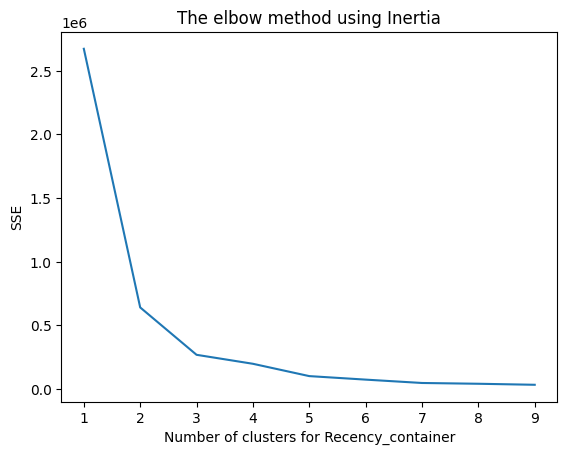

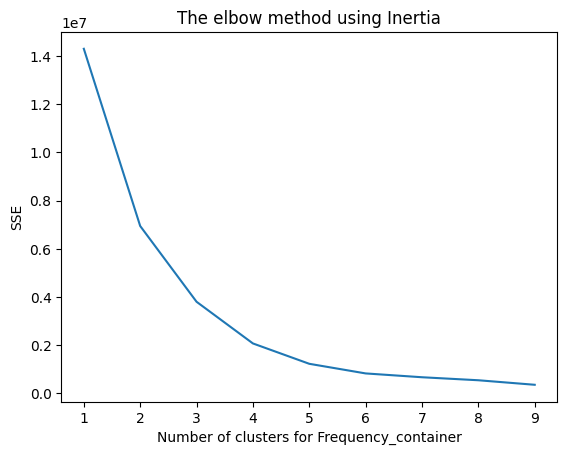

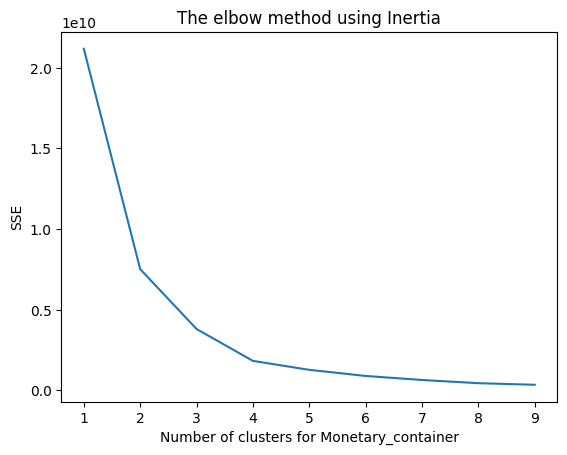

In [75]:
# Obtaining the optimal cluster for each RFM feature
# sum of squared errors

for key,val in container_list.items():
    optimal_cluster_no(val) 
    
    plt.figure()
    plt.plot(list(sse.keys()), list(sse.values()))
    plt.xlabel(f"Number of clusters for {key}")
    plt.ylabel("SSE")
    plt.title("The elbow method using Inertia")
    # plt.grid()
    plt.show()



Observation:
At 3, the elbow shows the change in the sum of squared error is minimal. The optimal cluster appears to be 3. We will be selecting 4 cluster according to this analysis to be more representative of business needs

In [76]:
#clustering with 4 optimal clusters 
def assign_clusters(df, container):
    for  key, val in container.items():
        kmeans =  KMeans(n_clusters=4, random_state=0, n_init= "auto")
        name  =  key.split('_', 1)[0] + "_Cluster"
        df[name] = kmeans.fit_predict(val)
    return df

In [77]:
#assigning clusters to the segment_full_df data which is the observation window data.
        
segment_full_df = assign_clusters(segment_full_df, container_list)
segment_full_df

,CustomerID,Recency,Frequency,Monetary,Recency_Cluster,Frequency_Cluster,Monetary_Cluster
0,12347,20,42,1018.77,1,0,0
1,12348,85,5,367.00,0,0,0
2,12352,99,21,608.76,0,0,0
3,12353,41,4,89.00,1,0,0
4,12354,69,58,1079.40,2,0,0
...,...,...,...,...,...,...,...
2325,18273,94,1,51.00,0,0,0
2326,18280,114,10,180.60,0,0,0
2327,18281,17,7,80.82,3,0,0
2328,18283,6,211,524.68,3,2,0


### Prediction window data

In [78]:
# Obtaining the Prediction window data which is the last 6 months of the time fram which is from 2011-07-01
last_6m_date =  pd.to_datetime('2011-07-01 00:00:00')
last_6m = df[df['InvoiceDate']> last_6m_date]


In [79]:
last_6m

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,YearQuarter
245903,558638,84836,12,2011-07-01 08:16:00,1.25,16317,United Kingdom,15.00,2011Q3
245904,558638,71459,24,2011-07-01 08:16:00,0.85,16317,United Kingdom,20.40,2011Q3
245905,558638,22784,3,2011-07-01 08:16:00,4.95,16317,United Kingdom,14.85,2011Q3
245906,558638,23145,12,2011-07-01 08:16:00,0.95,16317,United Kingdom,11.40,2011Q3
245907,558638,22674,12,2011-07-01 08:16:00,1.25,16317,United Kingdom,15.00,2011Q3
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,12,2011-12-09 12:50:00,0.85,12680,France,10.20,2011Q4
541905,581587,22899,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011Q4
541906,581587,23254,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011Q4
541907,581587,23255,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011Q4


In [80]:
# heights = [df['InvoiceDate'].iloc[0], df['StockCode'].iloc[0]]
# heights
# fig, ax = plt.subplots(figsize=(10,6))
# ax.bar

In [81]:
segment_full_df

,CustomerID,Recency,Frequency,Monetary,Recency_Cluster,Frequency_Cluster,Monetary_Cluster
0,12347,20,42,1018.77,1,0,0
1,12348,85,5,367.00,0,0,0
2,12352,99,21,608.76,0,0,0
3,12353,41,4,89.00,1,0,0
4,12354,69,58,1079.40,2,0,0
...,...,...,...,...,...,...,...
2325,18273,94,1,51.00,0,0,0
2326,18280,114,10,180.60,0,0,0
2327,18281,17,7,80.82,3,0,0
2328,18283,6,211,524.68,3,2,0


In [82]:
segment_full_df.groupby('Recency_Cluster')['Recency'].describe()

,count,mean,std,min,25%,50%,75%,max
Recency_Cluster,,,,,,,,
0,557.0,95.788151,13.183064,76.0,84.0,94.0,106.0,120.0
1,621.0,29.843800,7.574772,20.0,22.0,29.0,37.0,42.0
2,499.0,55.949900,9.662762,43.0,48.0,54.0,63.0,75.0
3,653.0,9.212864,5.441464,0.0,5.0,9.0,14.0,19.0


Observation:
 it appears that the cluster size is not represaentative of the mean recency in terms of ordinal encoding or ordinal values, in the description above,  	Customers with recency means around 95.788151 was clustered as 1 while Customers with recency means around 55.949900 were clustered as 3. The next code chunk will aim to categorise clusters ordinally. 

 secondly we are using a 1-4 quartile instead of the initial 0-3 clusters

In [83]:
segment_full_df.groupby('Recency_Cluster')['Recency'].mean().reset_index(name = "Recency_mean")


,Recency_Cluster,Recency_mean
0,0,95.788151
1,1,29.843800
2,2,55.949900
3,3,9.212864


In [84]:
segment_full_df

,CustomerID,Recency,Frequency,Monetary,Recency_Cluster,Frequency_Cluster,Monetary_Cluster
0,12347,20,42,1018.77,1,0,0
1,12348,85,5,367.00,0,0,0
2,12352,99,21,608.76,0,0,0
3,12353,41,4,89.00,1,0,0
4,12354,69,58,1079.40,2,0,0
...,...,...,...,...,...,...,...
2325,18273,94,1,51.00,0,0,0
2326,18280,114,10,180.60,0,0,0
2327,18281,17,7,80.82,3,0,0
2328,18283,6,211,524.68,3,2,0


In [85]:
#Ordering clusters ordinally categories
def order_clusters(cluster_name, target_name, df, ascending):
    df_new = df[cluster_name]
    df_new =  df.groupby(cluster_name)[target_name].mean().reset_index()
    
    df_new = df_new.sort_values(by=target_name, ascending = ascending).reset_index(drop =True)

    df_new["index"] =df_new.index #creating new index based on existing index ".index"

    # df.drop([cluster_name], axis =1, inplace=True)
    df_final =  pd.merge(df, df_new[[cluster_name, "index"]], on= cluster_name) #we are merging two dataframe sna dropping one of the columns at the point of merging

    df_final.drop([cluster_name], axis=1, inplace=True) #dropping the old cluster
    df_final.rename(columns={"index": cluster_name}, inplace=True) #renaming index as the new cluster  

    return df_final


segment_full_df = order_clusters('Recency_Cluster', 'Recency', segment_full_df, False)
segment_full_df

,CustomerID,Recency,Frequency,Monetary,Frequency_Cluster,Monetary_Cluster,Recency_Cluster
0,12347,20,42,1018.77,0,0,2
1,12348,85,5,367.00,0,0,0
2,12352,99,21,608.76,0,0,0
3,12353,41,4,89.00,0,0,2
4,12354,69,58,1079.40,0,0,1
...,...,...,...,...,...,...,...
2325,18273,94,1,51.00,0,0,0
2326,18280,114,10,180.60,0,0,0
2327,18281,17,7,80.82,0,0,3
2328,18283,6,211,524.68,2,0,3


In [86]:
segment_full_df.groupby('Recency_Cluster')['Recency'].describe()

,count,mean,std,min,25%,50%,75%,max
Recency_Cluster,,,,,,,,
0,557.0,95.788151,13.183064,76.0,84.0,94.0,106.0,120.0
1,499.0,55.949900,9.662762,43.0,48.0,54.0,63.0,75.0
2,621.0,29.843800,7.574772,20.0,22.0,29.0,37.0,42.0
3,653.0,9.212864,5.441464,0.0,5.0,9.0,14.0,19.0


Now clusters are arranged according to the order of most recency duration of customers with customers having lesser time from when they last visited for a purchase ordered under cluster 3

In [87]:
segment_full_df.head()

,CustomerID,Recency,Frequency,Monetary,Frequency_Cluster,Monetary_Cluster,Recency_Cluster
0,12347,20,42,1018.77,0,0,2
1,12348,85,5,367.00,0,0,0
2,12352,99,21,608.76,0,0,0
3,12353,41,4,89.00,0,0,2
4,12354,69,58,1079.40,0,0,1


Action : 4 optimal clusters is chosen

In [88]:
segment_full_df.groupby('Frequency_Cluster')['Frequency'].describe()

,count,mean,std,min,25%,50%,75%,max
Frequency_Cluster,,,,,,,,
0,2032.0,26.779528,20.057981,1.0,11.0,21.0,39.0,81.0
1,13.0,596.846154,167.533502,377.0,501.0,568.0,627.0,886.0
2,283.0,136.240283,53.051884,82.0,95.0,123.0,154.5,355.0
3,2.0,1663.000000,352.139177,1414.0,1538.5,1663.0,1787.5,1912.0


Applying ordinal categorizing: such that highly frequent score is ordered as cluster 3 > cluster 2 > cluster 1> cluster 0

In [89]:
segment_full_df.groupby('Frequency_Cluster')['Frequency'].mean()

Frequency_Cluster
0      26.779528
1     596.846154
2     136.240283
3    1663.000000
Name: Frequency, dtype: float64

In [90]:
segment_full_df = order_clusters('Frequency_Cluster','Frequency', segment_full_df, True)
segment_full_df

,CustomerID,Recency,Frequency,Monetary,Monetary_Cluster,Recency_Cluster,Frequency_Cluster
0,12347,20,42,1018.77,0,2,0
1,12348,85,5,367.00,0,0,0
2,12352,99,21,608.76,0,0,0
3,12353,41,4,89.00,0,2,0
4,12354,69,58,1079.40,0,1,0
...,...,...,...,...,...,...,...
2325,18273,94,1,51.00,0,0,0
2326,18280,114,10,180.60,0,0,0
2327,18281,17,7,80.82,0,3,0
2328,18283,6,211,524.68,0,3,1


In [91]:
segment_full_df.groupby('Frequency_Cluster')['Frequency'].describe()

,count,mean,std,min,25%,50%,75%,max
Frequency_Cluster,,,,,,,,
0,2032.0,26.779528,20.057981,1.0,11.0,21.0,39.0,81.0
1,283.0,136.240283,53.051884,82.0,95.0,123.0,154.5,355.0
2,13.0,596.846154,167.533502,377.0,501.0,568.0,627.0,886.0
3,2.0,1663.000000,352.139177,1414.0,1538.5,1663.0,1787.5,1912.0


In [92]:
segment_full_df.head()

,CustomerID,Recency,Frequency,Monetary,Monetary_Cluster,Recency_Cluster,Frequency_Cluster
0,12347,20,42,1018.77,0,2,0
1,12348,85,5,367.00,0,0,0
2,12352,99,21,608.76,0,0,0
3,12353,41,4,89.00,0,2,0
4,12354,69,58,1079.40,0,1,0


In [93]:
# checking summary of monetary  based on grouping by monetary clusters 
segment_full_df.groupby("Monetary_Cluster")['Monetary'].describe()


,count,mean,std,min,25%,50%,75%,max
Monetary_Cluster,,,,,,,,
0,2215.0,596.303982,526.697689,2.90,226.5300,397.400,809.9900,2641.53
1,12.0,21456.679167,7001.570105,13796.38,15704.0375,20348.755,25152.1325,35996.78
2,100.0,4706.975110,1993.927010,2665.63,3234.8475,3950.560,5544.1500,12150.84
3,3.0,65772.120000,11889.955698,52844.81,60538.1350,68231.460,72235.7750,76240.09


Ordinal encoding of the Monetary clusters, assigning higher cluster number to high revenue customers.

In [94]:
# calling the order_clusters function.
segment_full_df = order_clusters('Monetary_Cluster', 'Monetary', segment_full_df, True)


segment_full_df.groupby('Monetary_Cluster')['Monetary'].describe() #checking to see ordering took place

,count,mean,std,min,25%,50%,75%,max
Monetary_Cluster,,,,,,,,
0,2215.0,596.303982,526.697689,2.90,226.5300,397.400,809.9900,2641.53
1,100.0,4706.975110,1993.927010,2665.63,3234.8475,3950.560,5544.1500,12150.84
2,12.0,21456.679167,7001.570105,13796.38,15704.0375,20348.755,25152.1325,35996.78
3,3.0,65772.120000,11889.955698,52844.81,60538.1350,68231.460,72235.7750,76240.09


In [95]:
# adding 1 to each cluster value to create quartiles
clust = ['Recency_Cluster','Frequency_Cluster','Monetary_Cluster']
for col in clust:
    segment_full_df[col] = segment_full_df[col]+ 1
segment_full_df

,CustomerID,Recency,Frequency,Monetary,Recency_Cluster,Frequency_Cluster,Monetary_Cluster
0,12347,20,42,1018.77,3,1,1
1,12348,85,5,367.00,1,1,1
2,12352,99,21,608.76,1,1,1
3,12353,41,4,89.00,3,1,1
4,12354,69,58,1079.40,2,1,1
...,...,...,...,...,...,...,...
2325,18273,94,1,51.00,1,1,1
2326,18280,114,10,180.60,1,1,1
2327,18281,17,7,80.82,4,1,1
2328,18283,6,211,524.68,4,2,1


In [96]:
segment_full_df.groupby('Recency_Cluster')['Recency'].describe()

,count,mean,std,min,25%,50%,75%,max
Recency_Cluster,,,,,,,,
1,557.0,95.788151,13.183064,76.0,84.0,94.0,106.0,120.0
2,499.0,55.949900,9.662762,43.0,48.0,54.0,63.0,75.0
3,621.0,29.843800,7.574772,20.0,22.0,29.0,37.0,42.0
4,653.0,9.212864,5.441464,0.0,5.0,9.0,14.0,19.0


In [97]:
segment_full_df.groupby('Frequency_Cluster')['Frequency'].describe()

,count,mean,std,min,25%,50%,75%,max
Frequency_Cluster,,,,,,,,
1,2032.0,26.779528,20.057981,1.0,11.0,21.0,39.0,81.0
2,283.0,136.240283,53.051884,82.0,95.0,123.0,154.5,355.0
3,13.0,596.846154,167.533502,377.0,501.0,568.0,627.0,886.0
4,2.0,1663.000000,352.139177,1414.0,1538.5,1663.0,1787.5,1912.0


In [98]:
segment_full_df.groupby('Monetary_Cluster')['Monetary'].describe() #checking to see ordering took place

,count,mean,std,min,25%,50%,75%,max
Monetary_Cluster,,,,,,,,
1,2215.0,596.303982,526.697689,2.90,226.5300,397.400,809.9900,2641.53
2,100.0,4706.975110,1993.927010,2665.63,3234.8475,3950.560,5544.1500,12150.84
3,12.0,21456.679167,7001.570105,13796.38,15704.0375,20348.755,25152.1325,35996.78
4,3.0,65772.120000,11889.955698,52844.81,60538.1350,68231.460,72235.7750,76240.09


In [99]:
segment_full_df.head()

,CustomerID,Recency,Frequency,Monetary,Recency_Cluster,Frequency_Cluster,Monetary_Cluster
0,12347,20,42,1018.77,3,1,1
1,12348,85,5,367.00,1,1,1
2,12352,99,21,608.76,1,1,1
3,12353,41,4,89.00,3,1,1
4,12354,69,58,1079.40,2,1,1


In [100]:
# first of all changing the data type of the clusters from object data type to integer to enable addition.
segment_full_df.dtypes

CustomerID            object
Recency                int64
Frequency              int64
Monetary             float64
Recency_Cluster        int64
Frequency_Cluster      int64
Monetary_Cluster       int64
dtype: object

In [101]:
segment_full_df['RFMScore'] = segment_full_df['Recency_Cluster'].astype(str) + segment_full_df['Frequency_Cluster'].astype(str) + segment_full_df['Monetary_Cluster'].astype(str)


segment_full_df

,CustomerID,Recency,Frequency,Monetary,Recency_Cluster,Frequency_Cluster,Monetary_Cluster,RFMScore
0,12347,20,42,1018.77,3,1,1,311
1,12348,85,5,367.00,1,1,1,111
2,12352,99,21,608.76,1,1,1,111
3,12353,41,4,89.00,3,1,1,311
4,12354,69,58,1079.40,2,1,1,211
...,...,...,...,...,...,...,...,...
2325,18273,94,1,51.00,1,1,1,111
2326,18280,114,10,180.60,1,1,1,111
2327,18281,17,7,80.82,4,1,1,411
2328,18283,6,211,524.68,4,2,1,421


#### The usefulness of segmentation is to report on marketing spend.

In [102]:
segment_full_df.shape

(2330, 8)

In [103]:
segment_full_df.head()

,CustomerID,Recency,Frequency,Monetary,Recency_Cluster,Frequency_Cluster,Monetary_Cluster,RFMScore
0,12347,20,42,1018.77,3,1,1,311
1,12348,85,5,367.00,1,1,1,111
2,12352,99,21,608.76,1,1,1,111
3,12353,41,4,89.00,3,1,1,311
4,12354,69,58,1079.40,2,1,1,211


### Customer Segmentation (Descriptive segmentation) Option  1

### Rulebased segmentation based on rfm 
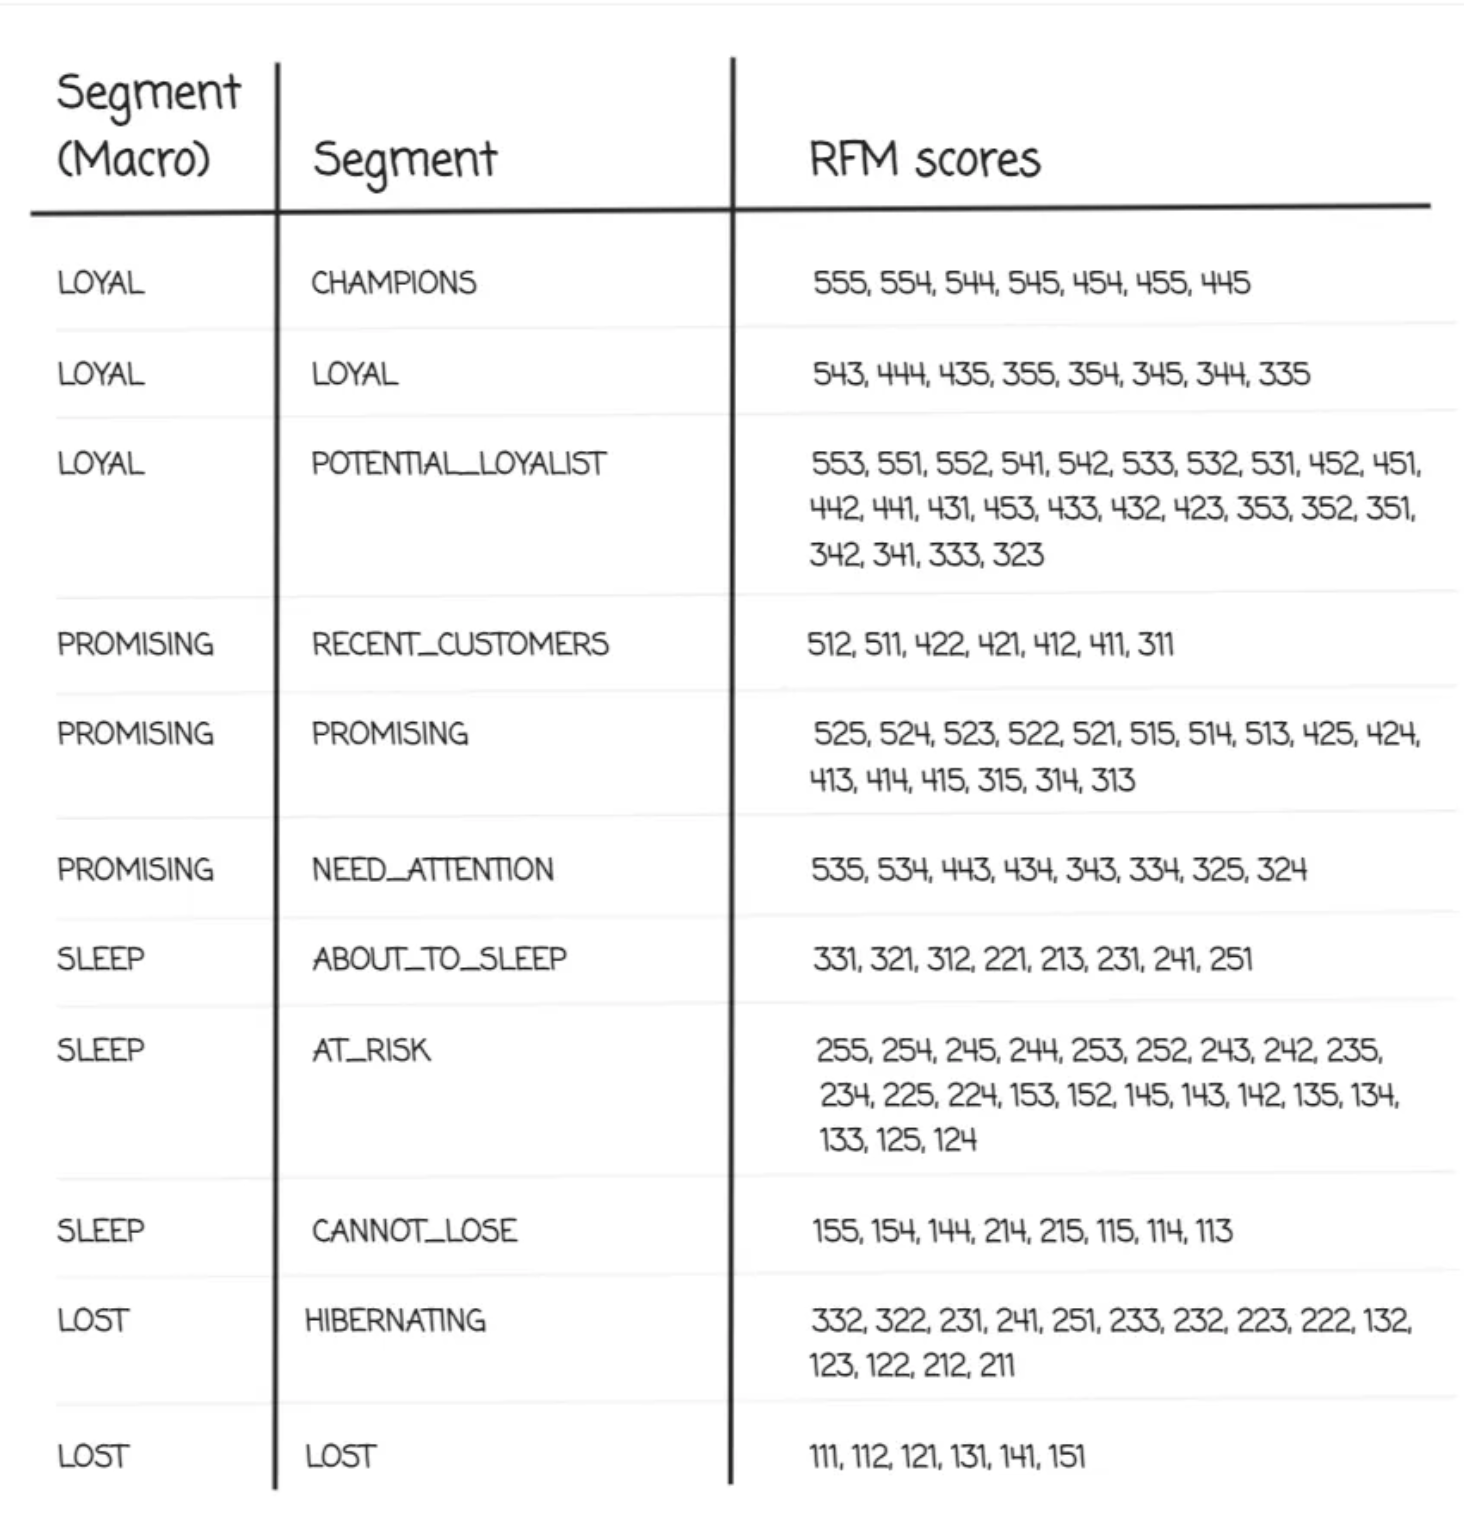



In [104]:
segment_map = {

'LOYAL': ['555','554','544','545','454','455','445',
'543','444','435','355','354','345','344','335',
'553','551','552','541','542','533','532','531','452','451',
'442','441','431','453','433','432','423','353','352','351',
'342','341','333','323'
],

'PROMISING': ['512','511','422','421','412','411','311',
'525','524','523','522','521','515','514','513','425','424',
'413','414','415','315','314','313', 
'535','534','443','434','343','334','325','324'],

'SLEEP': ['331','321','312','221','213','231','241','251',
'255','254','245','244','253','252','243','242','235',
'234','225','224','153','152','145','143','142',
'135','134','133','125','124',
'155','154','144','214','215','115','114','113'],

'LOST':[
'332','322','231','241','251','233','232','223','222','132',
'123','122','212','211',
'111','112','121','131','141','151']
}

In [105]:
# Function to get segment for each customer
segment_lookup = {score:segment for segment, rfmscore in segment_map.items() 
                    for score in rfmscore}

segment_full_df['Customer_Segment'] = segment_full_df['RFMScore'].map(segment_lookup)

In [106]:

segment_full_df

,CustomerID,Recency,Frequency,Monetary,Recency_Cluster,Frequency_Cluster,Monetary_Cluster,RFMScore,Customer_Segment
0,12347,20,42,1018.77,3,1,1,311,PROMISING
1,12348,85,5,367.00,1,1,1,111,LOST
2,12352,99,21,608.76,1,1,1,111,LOST
3,12353,41,4,89.00,3,1,1,311,PROMISING
4,12354,69,58,1079.40,2,1,1,211,LOST
...,...,...,...,...,...,...,...,...,...
2325,18273,94,1,51.00,1,1,1,111,LOST
2326,18280,114,10,180.60,1,1,1,111,LOST
2327,18281,17,7,80.82,4,1,1,411,PROMISING
2328,18283,6,211,524.68,4,2,1,421,PROMISING


In [107]:
segment_full_df['Customer_Segment'].value_counts()

Customer_Segment
PROMISING    1182
LOST         1039
SLEEP          94
LOYAL          15
Name: count, dtype: int64

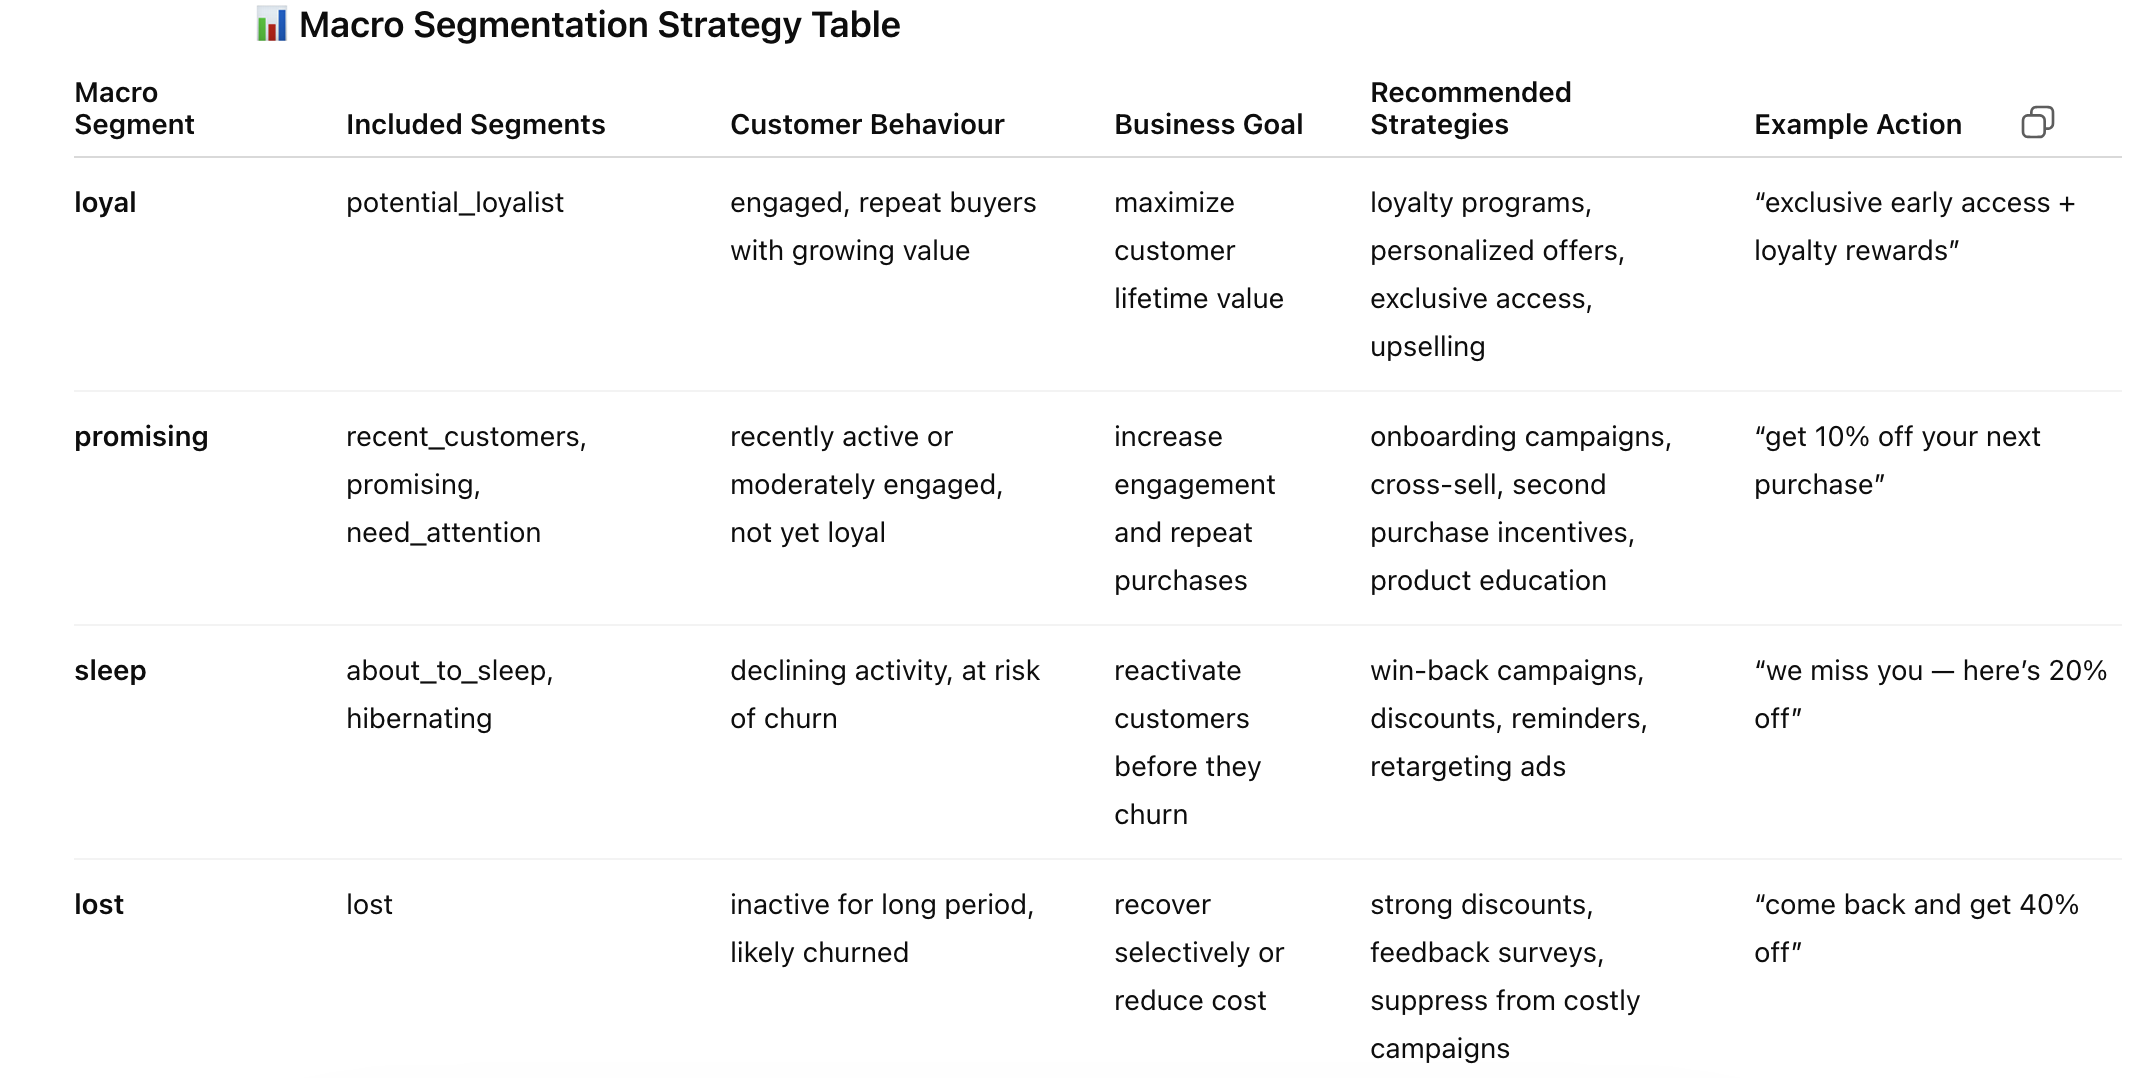

In [108]:
segment_full_df.head()

,CustomerID,Recency,Frequency,Monetary,Recency_Cluster,Frequency_Cluster,Monetary_Cluster,RFMScore,Customer_Segment
0,12347,20,42,1018.77,3,1,1,311,PROMISING
1,12348,85,5,367.00,1,1,1,111,LOST
2,12352,99,21,608.76,1,1,1,111,LOST
3,12353,41,4,89.00,3,1,1,311,PROMISING
4,12354,69,58,1079.40,2,1,1,211,LOST


In [123]:
# obtaining the cluster summary
segment_summary = segment_full_df.groupby('Customer_Segment')\
                    .agg({"Recency": "mean",
                        "Frequency": "mean",
                        "Monetary": "mean",
                        "CustomerID": "count" })\
                            .rename(columns={"CustomerID": "Customers"})
segment_summary

,Recency,Frequency,Monetary,Customers
Customer_Segment,,,,
LOST,77.063523,25.999038,499.107999,1039
LOYAL,4.600000,591.400000,13120.292000,15
PROMISING,18.901861,48.426396,1175.380474,1182
SLEEP,35.553191,116.308511,1506.702447,94


### Customer Segmentation (Descriptive segmentation) Option  2

### Using Kmeans clustering
 - log transform skewed data
 - scale features (standard scaler)
 - apply kmeans on rfm 
 - label clusters based on entroid beahavior  
 reference : https://github.com/maissaladjimi/RFM_Customer_Segmentation/blob/main/RFM_Segmentation.ipynb



Text(0.5, 1.0, 'Outliers Variable Distribution')

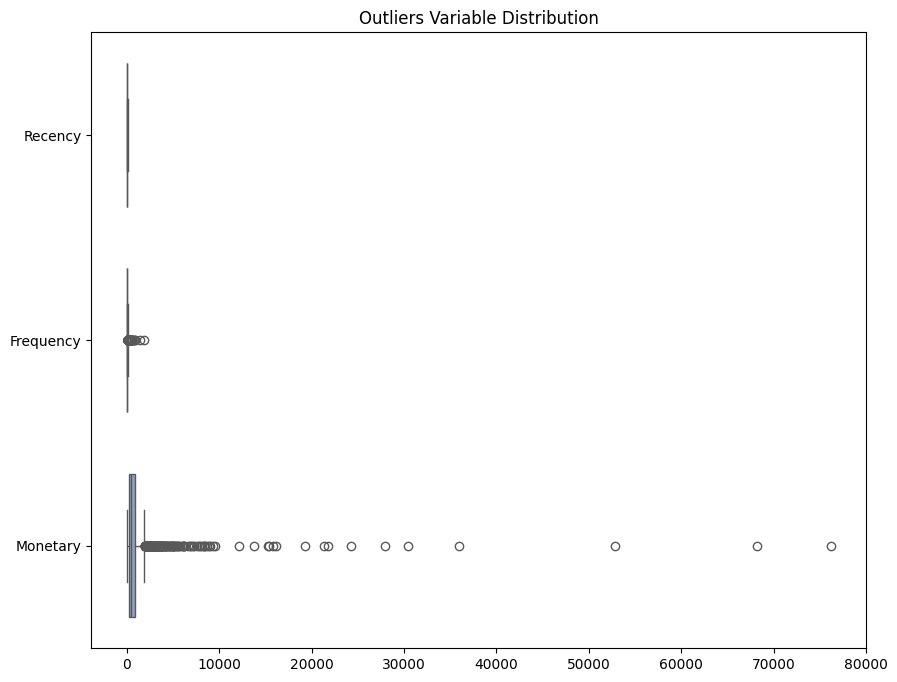

In [110]:
# Plotting outliers 
#Boxplot to see outliers
attributes = ['Recency', 'Frequency', 'Monetary']
clust  = ['Recency_Cluster', 'Frequency_Cluster', 'Monetary_Cluster']

plt.figure(figsize=(10, 8))

sns.boxplot(data = segment_full_df[attributes], orient="h", palette="Set2" ,whis=1.5,saturation=1, width=0.7)
plt.title("Outliers Variable Distribution", fontsize = 12)

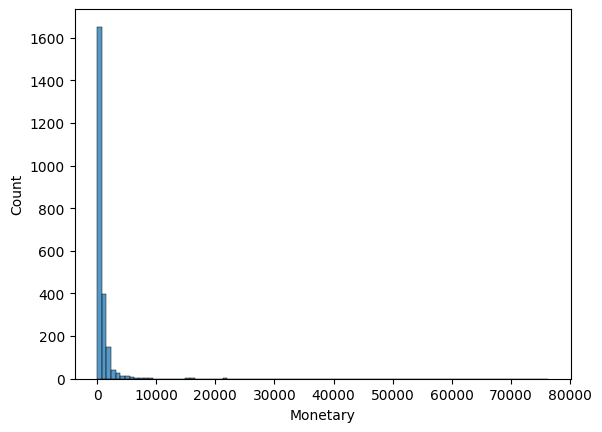

In [111]:
sns.histplot(segment_full_df['Monetary'])
plt.show()

We have an evidence based on the box plot of the Monetary value to log transform - log transform is usually used when we have large numbers, which can be seen by the outliers. our monetary values do not follow a normal distribution. Applying standardsization before log transformation is usually advised

In [112]:
# Applying standardsization
from sklearn.preprocessing import StandardScaler, normalize

# obtaining rfm values
rfm = segment_full_df[clust].copy()

# log transformation to reduce frequency and monetary skewness
rfm_log = np.log1p(rfm)


# normalization
scaler = StandardScaler()
scaled = scaler.fit_transform(rfm_log)

# convert scaled features to a dataframe for clustering prep

rfm_scaled =  pd.DataFrame(scaled, columns = ['Recency', 'Frequency', 'Monetary'], index = rfm.index )

rfm_scaled

,Recency,Frequency,Monetary
0,0.476888,-0.376793,-0.220191
1,-1.529213,-0.376793,-0.220191
2,-1.529213,-0.376793,-0.220191
3,0.476888,-0.376793,-0.220191
4,-0.355719,-0.376793,-0.220191
...,...,...,...
2325,-1.529213,-0.376793,-0.220191
2326,-1.529213,-0.376793,-0.220191
2327,1.122708,-0.376793,-0.220191
2328,1.122708,2.457581,-0.220191


In [113]:
rfm_scaled

,Recency,Frequency,Monetary
0,0.476888,-0.376793,-0.220191
1,-1.529213,-0.376793,-0.220191
2,-1.529213,-0.376793,-0.220191
3,0.476888,-0.376793,-0.220191
4,-0.355719,-0.376793,-0.220191
...,...,...,...
2325,-1.529213,-0.376793,-0.220191
2326,-1.529213,-0.376793,-0.220191
2327,1.122708,-0.376793,-0.220191
2328,1.122708,2.457581,-0.220191


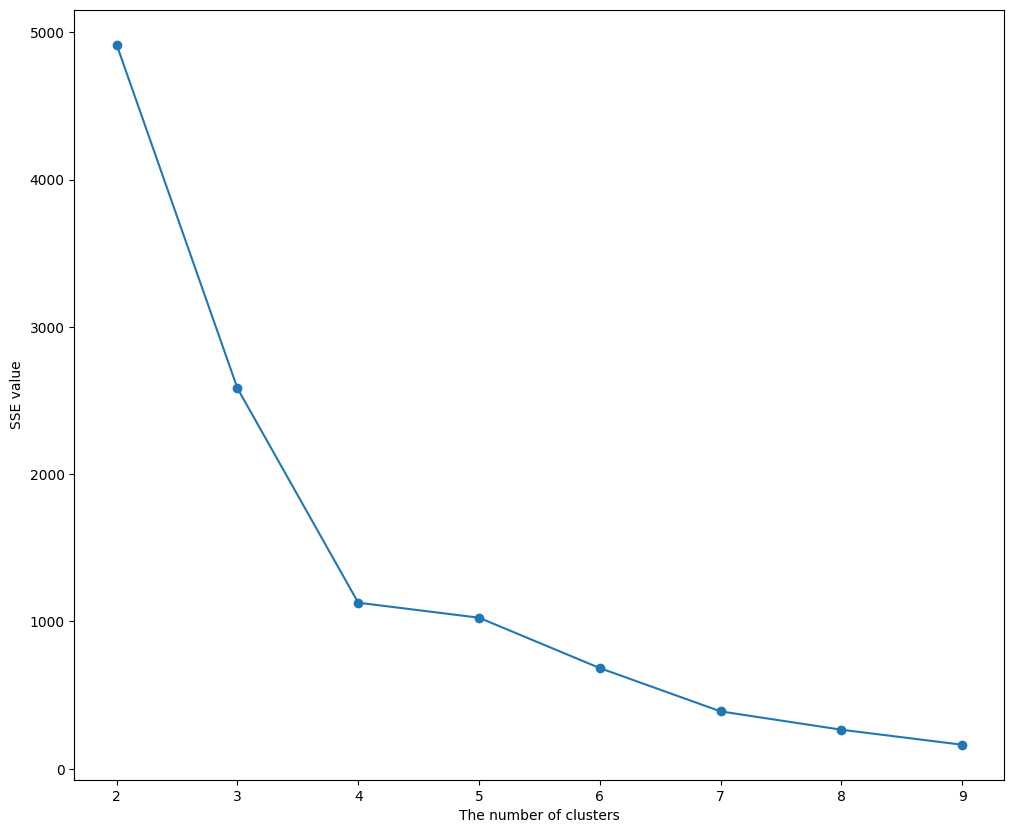

In [114]:
# Finding optimal number of clusters using Elbow method
sse = []

k_range = range(2,10)

for k in range(2,10):
    kmeans = KMeans(n_clusters = k, random_state=42)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)

# Plotting the sse to determine the optimal number of clusters
plt.figure(figsize=(12,10))
plt.plot(k_range, sse, marker = 'o')
plt.xlabel("The number of clusters")
plt.ylabel("SSE value")
plt.show()

#### We have four optimal number of clusters using our elbow method

In [115]:
# Fitting the model with the optimal cluster
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(rfm_scaled) 

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.groupby('Cluster')[clust].mean()

rfm


,Recency_Cluster,Frequency_Cluster,Monetary_Cluster,Cluster
0,3,1,1,0
1,1,1,1,1
2,1,1,1,1
3,3,1,1,0
4,2,1,1,1
...,...,...,...,...
2325,1,1,1,1
2326,1,1,1,1
2327,4,1,1,0
2328,4,2,1,3


In [116]:
rfm

,Recency_Cluster,Frequency_Cluster,Monetary_Cluster,Cluster
0,3,1,1,0
1,1,1,1,1
2,1,1,1,1
3,3,1,1,0
4,2,1,1,1
...,...,...,...,...
2325,1,1,1,1
2326,1,1,1,1
2327,4,1,1,0
2328,4,2,1,3


In [117]:
segment_full_df

,CustomerID,Recency,Frequency,Monetary,Recency_Cluster,Frequency_Cluster,Monetary_Cluster,RFMScore,Customer_Segment
0,12347,20,42,1018.77,3,1,1,311,PROMISING
1,12348,85,5,367.00,1,1,1,111,LOST
2,12352,99,21,608.76,1,1,1,111,LOST
3,12353,41,4,89.00,3,1,1,311,PROMISING
4,12354,69,58,1079.40,2,1,1,211,LOST
...,...,...,...,...,...,...,...,...,...
2325,18273,94,1,51.00,1,1,1,111,LOST
2326,18280,114,10,180.60,1,1,1,111,LOST
2327,18281,17,7,80.82,4,1,1,411,PROMISING
2328,18283,6,211,524.68,4,2,1,421,PROMISING


In [118]:
# extract feature of rfm inclusive of customerid
segment_full_df_2 = segment_full_df[["CustomerID", "Recency", "Frequency", "Monetary"]]

# join on index to add the customer_id 
result_df = segment_full_df_2.join(rfm) 

# drop rfm clusters 
result_df.drop(clust, axis=1)

cluster_summary =  result_df.groupby('Cluster')\
                    .agg({"Recency": "mean",
                        "Frequency": "mean",
                        "Monetary": "mean",
                        "CustomerID": "count" })\
                            .rename(columns={"CustomerID": "Customers"}) # ranmeinginf customer_id because we are counting 

cluster_summary


,Recency,Frequency,Monetary,Customers
Cluster,,,,
0,20.811111,30.847475,617.976636,990
1,77.585586,21.841842,402.366286,999
2,17.782609,186.939130,8047.774096,115
3,25.070796,133.628319,1358.639513,226


In [119]:
result_df

,CustomerID,Recency,Frequency,Monetary,Recency_Cluster,Frequency_Cluster,Monetary_Cluster,Cluster
0,12347,20,42,1018.77,3,1,1,0
1,12348,85,5,367.00,1,1,1,1
2,12352,99,21,608.76,1,1,1,1
3,12353,41,4,89.00,3,1,1,0
4,12354,69,58,1079.40,2,1,1,1
...,...,...,...,...,...,...,...,...
2325,18273,94,1,51.00,1,1,1,1
2326,18280,114,10,180.60,1,1,1,1
2327,18281,17,7,80.82,4,1,1,0
2328,18283,6,211,524.68,4,2,1,3


In [120]:
# obtaining the cluster index  which is the rfm values from the cluster divided by the data average
cluster_index = cluster_summary[['Recency','Frequency','Monetary']]\
      / segment_full_df[['Recency','Frequency','Monetary']].mean() #data average

cluster_index.rename(columns ={'Recency':'recency_index','Frequency':'frequency_index','Monetary':'monetary_index'})


,recency_index,frequency_index,monetary_index
Cluster,,,
0,0.458221,0.690724,0.641001
1,1.708288,0.489073,0.417358
2,0.391539,4.185861,8.347617
3,0.552011,2.992148,1.409260


Result Intepretation of the recency index
| Value   | Meaning                 |
| ------- | ----------------------- |
| **= 1** | Same as dataset average |
| **> 1** | Above average           |
| **< 1** | Below average           |


 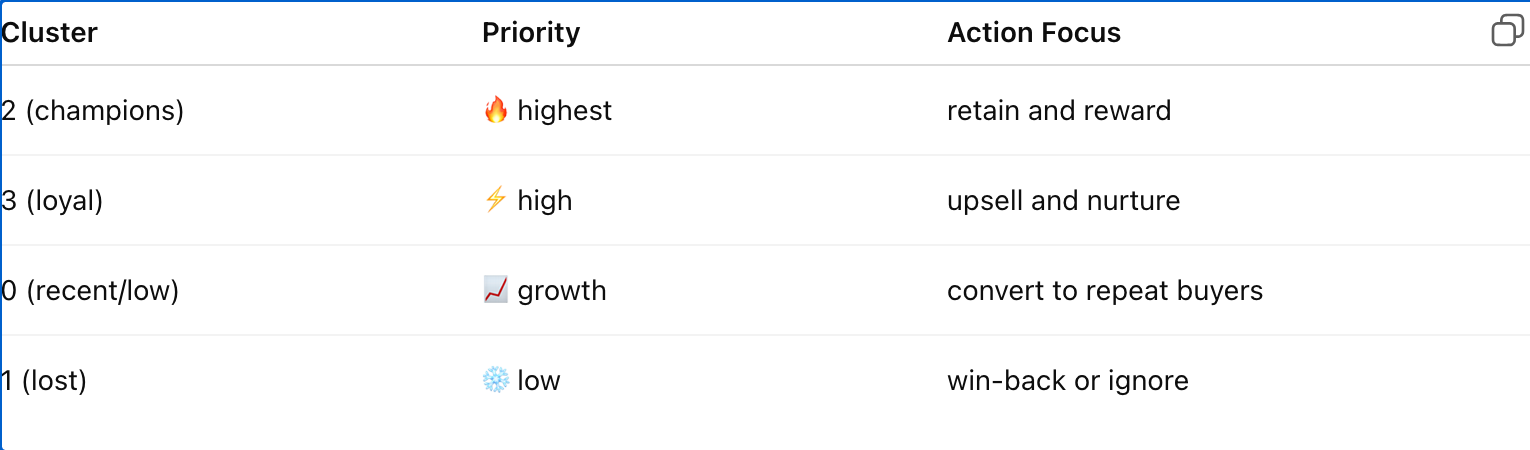

 
 #### Recommendation - three strategic priorities:

1️⃣ Protect Cluster 2 (Champions)
They generate the most revenue.

2️⃣ Retain Cluster 1 (dormant)
win or ignore customers

3️⃣ Grow Cluster 3 (loyal Customers)
upsell and nurture

4. Convert Cluster 0 (recent/low customer)
convert to repeat buyers


In [121]:
## Assigning segement to each customer
def label_clusters(cluster):
    if cluster == 0:
        return 'Recent Customers'
    elif cluster == 1:
        return "Dormant Customers"
    elif cluster  == 2:
        return "Champion"
    else: 
        return "loyal Customer"

result_df["customer_segment"] =result_df['Cluster'].apply(label_clusters)
result_df

,CustomerID,Recency,Frequency,Monetary,Recency_Cluster,Frequency_Cluster,Monetary_Cluster,Cluster,customer_segment
0,12347,20,42,1018.77,3,1,1,0,Recent Customers
1,12348,85,5,367.00,1,1,1,1,Dormant Customers
2,12352,99,21,608.76,1,1,1,1,Dormant Customers
3,12353,41,4,89.00,3,1,1,0,Recent Customers
4,12354,69,58,1079.40,2,1,1,1,Dormant Customers
...,...,...,...,...,...,...,...,...,...
2325,18273,94,1,51.00,1,1,1,1,Dormant Customers
2326,18280,114,10,180.60,1,1,1,1,Dormant Customers
2327,18281,17,7,80.82,4,1,1,0,Recent Customers
2328,18283,6,211,524.68,4,2,1,3,loyal Customer


In [124]:
# obtaining the cluster summary
segment_summary = result_df.groupby('customer_segment')\
                    .agg({"Recency": "mean",
                        "Frequency": "mean",
                        "Monetary": "mean",
                        "CustomerID": "count" })\
                            .rename(columns={"CustomerID": "Customer Count"})
segment_summary.reset_index()
segment_summary.to_csv("/Users/helensoremekun/Desktop/deployed_CLV/models/current_state_segment_summary.csv")

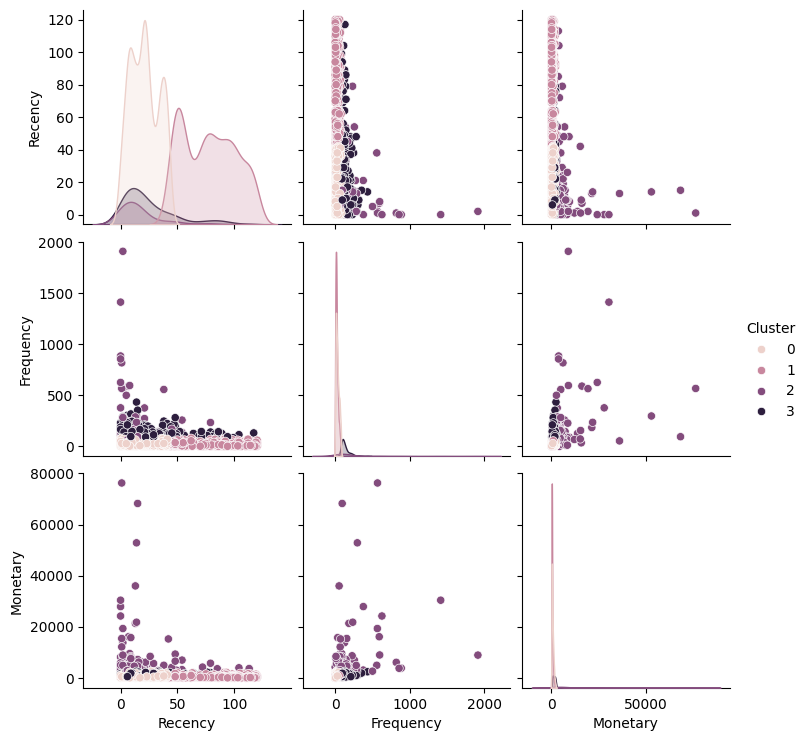

In [ ]:
# Visualizing rfm

sns.pairplot(
    result_df,
    vars=['Recency','Frequency','Monetary'],
    hue='Cluster'
)
plt.show()

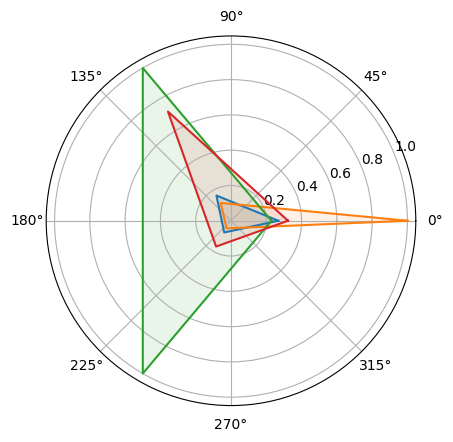

In [ ]:
from math import pi

features = ['Recency','Frequency','Monetary']
data = cluster_summary[features]

# Normalize values
data_norm = data / data.max()

angles = [n / float(len(features)) * 2 * pi for n in range(len(features))]
angles += angles[:1]

fig = plt.figure()

for i in range(len(data_norm)):
    values = data_norm.iloc[i].tolist()
    values += values[:1]

    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.1)

plt.show()

| Cluster | Segment          | Behaviour                         |
| ------- | ---------------- | --------------------------------- |
| 0       | Recent Customers | New buyers with low spending      |
| 1       | Dormant Customers   | Inactive and low value            |
| 2       | Champions        | Very high value customers         |
| 3       | Loyal Customers  | Frequent and valuable             |

In [ ]:
#Revenue Contribution Analysis
#Businesses care about how much revenue each cluster generates.

revenue_cluster = result_df.groupby('Cluster')['Monetary'].sum()
revenue_cluster


Cluster
0    611796.870
1    401963.920
2    925494.021
3    307052.530
Name: Monetary, dtype: float64

There's a huge need to retain at risk customer and convert high paying customers to champion

#### I can say option 2 appears to be more reliable

### What i have done above is obtain segments for customers. this is descriptive analytics based on raw features and it is useful for marketing optimization.

## Predictive Analytics

Steps:
1. We'd start with predicting future transactions, monetary value of transactions, and prediction of CLTV values using Beta-Geometric/Negative Binomial Distribution, Gamma-Gamma statistical methods.  
https://medium.com/@yassirafif/projecting-customer-lifetime-value-using-the-bg-nbd-and-the-gamma-gamma-models-9a937c60fe7f 
Beta-Geometric/Negative Binomial Distribution are really useful in non contractual settings 

https://www.pymc-labs.com/blog-posts/pareto-nbd

2. Then multiclass- classification with Random Forest to predict customer lifetime value for 

- first we will drop the monetary values and the lifetime values and its clusters possibliy because that is our target, then other features will be the used as predictors/independent variables.
-  cluster lifetime values
- then we can now do a multiclass classification with 


In [ ]:
# the next step is to using Beta-Geometric/Negative Binomial Distribution, Gamma-Gamma statistical methods to predict CLVs.this will be my baseline model
# making sure this features are added the recency, frequency, monetary value, time seems first purchase, inter-purchase time stats(mean gaps, max, variance, min), purchase velocity trend.

# Then build survival models and frequency models. get P(Churn), get CLV values 
# Predict forward CLV for the next 90 days.
# then tailor the solution i get from this for marketing.


In [ ]:
# Importing necessary libraries for Beta-Geometric/Negative Binomial Distribution, Gamma-Gamma statistical methods to predict CLVs

from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter
from lifetimes.utils import calibration_and_holdout_data
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases
import datetime  as dt
from decimal import Decimal
from sklearn.metrics import mean_squared_error


In [ ]:
df.dropna(inplace=True)

In [ ]:
# Dropping rows with negative quantity.
df = df[~df['Quantity'] < 0]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397679 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397679 non-null  object        
 1   StockCode    397679 non-null  object        
 2   Quantity     397679 non-null  int64         
 3   InvoiceDate  397679 non-null  datetime64[ns]
 4   UnitPrice    397679 non-null  float64       
 5   CustomerID   397679 non-null  object        
 6   Country      397679 non-null  object        
 7   TotalSales   397679 non-null  float64       
 8   YearQuarter  397679 non-null  period[Q-DEC] 
dtypes: datetime64[ns](1), float64(2), int64(1), object(4), period[Q-DEC](1)
memory usage: 30.3+ MB


In [ ]:
# computing the monetary and tenure metrics 
future_df =  df.copy()

future_df['Monetary'] = future_df['Quantity'] * future_df['UnitPrice']
future_df['Monetary']= future_df['Monetary'].apply(Decimal)
future_df['Monetary']


0         15.2999999999999989341858963598497211933135986...
1         20.3399999999999998578914528479799628257751464...
2                                                        22
3         20.3399999999999998578914528479799628257751464...
4         20.3399999999999998578914528479799628257751464...
                                ...                        
541904    10.1999999999999992894572642398998141288757324...
541905    12.6000000000000014210854715202003717422485351...
541906    16.6000000000000014210854715202003717422485351...
541907    16.6000000000000014210854715202003717422485351...
541908    14.8500000000000014210854715202003717422485351...
Name: Monetary, Length: 397679, dtype: object

In [ ]:
# Computing the summary data "summary_data_from_transaction_data" is from the lifetimes library

df_rfmt = summary_data_from_transaction_data(transactions=future_df,\
                                             customer_id_col='CustomerID',
                                              datetime_col = 'InvoiceDate',
                                               monetary_value_col = 'Monetary')

# dropping any missing values
df_rfmt = df_rfmt.dropna(subset=['frequency','recency','T','monetary_value'])
df_rfmt

,frequency,recency,T,monetary_value
CustomerID,,,,
12347,6.0,365.0,367.0,599.701667
12348,3.0,283.0,358.0,301.480000
12349,0.0,0.0,18.0,0.000000
12350,0.0,0.0,310.0,0.000000
12352,6.0,260.0,296.0,258.831667
...,...,...,...,...
18280,0.0,0.0,277.0,0.000000
18281,0.0,0.0,180.0,0.000000
18282,1.0,119.0,126.0,77.840000


The recency variable is a measure of the time elapsed since the customer’s last purchase.
The frequency corresponds to the number of orders placed by a customer.
The monetary metric shows the total revenue generated by each customer.
Tenure, or T, represents how long a given customer has been with the company.

In [ ]:
# Obtaining the calibaration period - to fit the model and the observation or holdout period to test the model

# size of the data

time_diff =  future_df['InvoiceDate'].max() - future_df['InvoiceDate'].min()
time_diff


Timedelta('373 days 04:24:00')

In [ ]:
# We will use 200 days to fit the model and 173 days to test the model
cal_end_date = future_df['InvoiceDate'].min() + dt.timedelta(days =200)
cal_end_date
obs_end_date =  cal_end_date + (time_diff - dt.timedelta(days=200)) # or just future_df['InvoiceDate'].max()
obs_end_date

Timestamp('2011-12-09 12:50:00')

In [ ]:
# splitting our dataset with the calibration_and_holdout_data method
df_rfmt_cal =  calibration_and_holdout_data(transactions=future_df,
                                            customer_id_col="CustomerID",
                                            datetime_col= "InvoiceDate",
                                            calibration_period_end= cal_end_date,
                                            observation_period_end= obs_end_date)

df_rfmt_cal.head()

,frequency_cal,recency_cal,T_cal,frequency_holdout,duration_holdout
CustomerID,,,,,
12347,3.0,184.0,194.0,3.0,173.0
12348,2.0,110.0,185.0,1.0,173.0
12350,0.0,0.0,137.0,0.0,173.0
12352,3.0,34.0,123.0,3.0,173.0
12353,0.0,0.0,31.0,0.0,173.0


In [ ]:
# Finding the best L2 regularization for the BG/NBD model source: https://medium.com/@yassirafif/projecting-customer-lifetime-value-using-the-bg-nbd-and-the-gamma-gamma-models-9a937c60fe7f

l2_coefs = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
l2_list = []

rmse_list = []

for coef in l2_coefs:

    # Fitting the model using calibration dataset
    model =  BetaGeoFitter(penalizer_coef=coef)
    model.fit(df_rfmt_cal['frequency_cal'], 
              df_rfmt_cal['recency_cal'],
               df_rfmt_cal['T_cal'])

    # Predicting the frequency of the holdout period for all customers and converting to a dataframe
    pred_freq = pd.DataFrame(model.predict(df_rfmt_cal['duration_holdout'],
                  df_rfmt_cal['frequency_cal'], 
                  df_rfmt_cal['recency_cal'],
                  df_rfmt_cal['T_cal']), columns = ['pred_frequency']).reset_index()

    # merging the two dataframes 
    new_df = df_rfmt_cal.reset_index().merge(pred_freq, on ='CustomerID').dropna()

    # Computing the rmse score
    rmse_score = np.sqrt(mean_squared_error(new_df['frequency_holdout'], new_df['pred_frequency']))
    l2_list.append(coef)
    rmse_list.append(rmse_score)

# Getting the results
resl = pd.DataFrame(np.array(rmse_list), columns=['rmse_score'])\
        .merge(pd.DataFrame(np.array(l2_list), columns = ['L2 coefs']), right_index=True, left_index=True)
    
resl

/Users/helensoremekun/Desktop/Customer_LifeTime_Prediction/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/helensoremekun/Desktop/Customer_LifeTime_Prediction/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/helensoremekun/Desktop/Customer_LifeTime_Prediction/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/helensoremekun/Desktop/Customer_LifeTime_Prediction/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/helensoremekun/Desktop/Customer_LifeTime_Prediction/.venv/lib/python3.9/site-packages/pandas/

,rmse_score,L2 coefs
0,2.396716,0.3
1,2.388255,0.4
2,2.376561,0.5
3,2.372486,0.6
4,2.366446,0.7
5,2.363544,0.8
6,2.362222,0.9
7,2.368743,1.0


#### Inference:
The lowest rmse_score is 2.3622, our optimal best L2 coefficient is 0.9

#### BetaGeo assumptions are

In [ ]:
# Fitting the model using the cailibration dataset with the optimal best L2 coefficient
model =  BetaGeoFitter(penalizer_coef=0.90)
model.fit(df_rfmt_cal['frequency_cal'], 
        df_rfmt_cal['recency_cal'], 
        df_rfmt_cal['T_cal'])

# Predicting the requency of the holdout period for all customers and converting to a dataframe
pred_freq = pd.DataFrame(model.predict(df_rfmt_cal['duration_holdout'],
                df_rfmt_cal['frequency_cal'], 
                df_rfmt_cal['recency_cal'],
                df_rfmt_cal['T_cal']), columns = ['pred_frequency']).reset_index()

# merging the two dataframes 
new_df = df_rfmt_cal.reset_index().merge(pred_freq, on ='CustomerID').dropna()
new_df

/Users/helensoremekun/Desktop/Customer_LifeTime_Prediction/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,CustomerID,frequency_cal,recency_cal,T_cal,frequency_holdout,duration_holdout,pred_frequency
0,12347,3.0,184.0,194.0,3.0,173.0,2.624806
1,12348,2.0,110.0,185.0,1.0,173.0,1.902780
2,12350,0.0,0.0,137.0,0.0,173.0,0.299564
3,12352,3.0,34.0,123.0,3.0,173.0,3.911064
4,12353,0.0,0.0,31.0,0.0,173.0,0.899245
...,...,...,...,...,...,...,...
2853,18272,1.0,21.0,73.0,4.0,173.0,2.304255
2854,18273,0.0,0.0,84.0,2.0,173.0,0.449369
2855,18280,0.0,0.0,104.0,0.0,173.0,0.378026
2857,18283,5.0,159.0,164.0,8.0,173.0,4.909781


#### validation of BG/NBD model

<Axes: title={'center': 'Actual Purchases in Holdout Period vs Predicted Purchases'}, xlabel='Purchases in calibration period', ylabel='Average of Purchases in Holdout Period'>

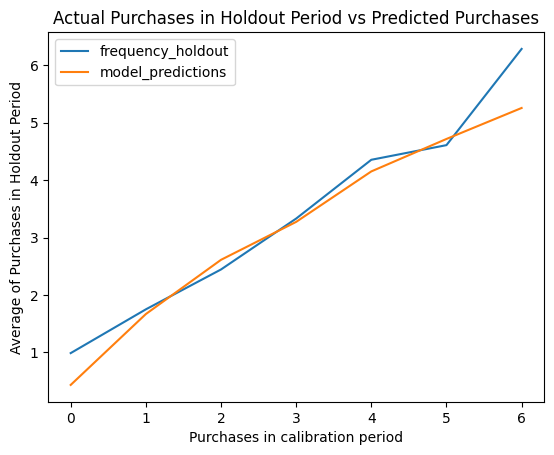

In [ ]:
# Plot of the plot_calibration_purchases_vs_holdout_purchases

plot_calibration_purchases_vs_holdout_purchases(model = model, kind="frequency_cal", calibration_holdout_matrix=new_df)

The model appears to be  doing a good job predicting the frequencies in the holdout dataset.
My model appears to be reliable


In [ ]:
# Filtering data first
df_rfmt.dropna(inplace = True)

# Getting rid of negative values
df_rfmt = df_rfmt[df_rfmt['monetary_value']>0]

# Predicting the number of purchases that each customer will make in the next 3 months = 90 days

df_rfmt["predicted_purchases_90days"] = model.conditional_expected_number_of_purchases_up_to_time(90,
                                                            df_rfmt['frequency'],
                                                            df_rfmt['recency'],
                                                            df_rfmt['T'])



df_rfmt

,frequency,recency,T,monetary_value,predicted_purchases_90days
CustomerID,,,,,
12347,6.0,365.0,367.0,599.701667,1.452337
12348,3.0,283.0,358.0,301.480000,0.776005
12352,6.0,260.0,296.0,258.831667,1.776718
12356,2.0,303.0,325.0,269.905000,0.590377
12358,1.0,149.0,150.0,683.200000,0.665600
...,...,...,...,...,...
18272,5.0,244.0,246.0,487.752000,1.772372
18273,2.0,255.0,257.0,76.500000,0.734327
18282,1.0,119.0,126.0,77.840000,0.773472


In [ ]:
# Validating Gamma Gamma assumption
# Checks for correlation between monetary and frequency value - if correlation is high both can't be used to model

df_rfmt[['frequency','monetary_value']].corr()


,frequency,monetary_value
frequency,1.000000,0.174162
monetary_value,0.174162,1.000000


#### GammaGamma assumptions are:

In [ ]:
# extracting customers with frequency > 0 for gamma gamm distribution
df_gg = df_rfmt[df_rfmt['frequency'] > 0]

# Fitting Gamma Gamma model to predict spending of each customer in the next 6 months
gg_model=  GammaGammaFitter(penalizer_coef=0.01)
gg_model.fit(df_gg['frequency'], df_gg['monetary_value'])

# predicting conditional expected average  using the method conditional_expected_average_profit
df_rfmt['pred_monetary'] = gg_model.conditional_expected_average_profit(
                                                df_gg['frequency'], 
                                                df_gg['monetary_value']
                                                )
df_rfmt

,frequency,recency,T,monetary_value,predicted_purchases_90days,pred_monetary
CustomerID,,,,,,
12347,6.0,365.0,367.0,599.701667,1.452337,618.508631
12348,3.0,283.0,358.0,301.480000,0.776005,321.623296
12352,6.0,260.0,296.0,258.831667,1.776718,267.305100
12356,2.0,303.0,325.0,269.905000,0.590377,298.038088
12358,1.0,149.0,150.0,683.200000,0.665600,834.102559
...,...,...,...,...,...,...
18272,5.0,244.0,246.0,487.752000,1.772372,506.360654
18273,2.0,255.0,257.0,76.500000,0.734327,85.908496
18282,1.0,119.0,126.0,77.840000,0.773472,98.961328


In [ ]:
# Predicting Customer Lifetime Value CLV for the next 3 months = 90 days  using the method customer_lifetime_value uisng frequency, recency, T, monetary_value and the time in months 
df_rfmt['CLV'] =  gg_model.customer_lifetime_value(
    model, 
    df_rfmt['frequency'],
    df_rfmt['recency'],
    df_rfmt['T'],
    df_rfmt['monetary_value'], 
    time = 3, # it expects its in  months
    discount_rate=0.01,
    freq = 'D', )
df_rfmt

,frequency,recency,T,monetary_value,predicted_purchases_90days,pred_monetary,CLV
CustomerID,,,,,,,
12347,6.0,365.0,367.0,599.701667,1.452337,618.508631,880.612547
12348,3.0,283.0,358.0,301.480000,0.776005,321.623296,244.671630
12352,6.0,260.0,296.0,258.831667,1.776718,267.305100,465.583222
12356,2.0,303.0,325.0,269.905000,0.590377,298.038088,172.493417
12358,1.0,149.0,150.0,683.200000,0.665600,834.102559,544.257010
...,...,...,...,...,...,...,...
18272,5.0,244.0,246.0,487.752000,1.772372,506.360654,879.805231
18273,2.0,255.0,257.0,76.500000,0.734327,85.908496,61.843923
18282,1.0,119.0,126.0,77.840000,0.773472,98.961328,75.038124


In [ ]:
# Using quantile segmentation to get a clean ranking-based segmentation
#handling outliers first by log transforming
df_rfmt['CLV_log'] = np.log1p(df_rfmt['CLV'])
 
df_rfmt['clv_segment'] = pd.qcut(
    df_rfmt['CLV_log'],
    q=5,
    labels=['Low CLV','Occasional CLV','Active CLV','Loyal CLV','Champions CLV']
)

df_rfmt.groupby('clv_segment')['CLV'].agg(['mean','count'])


,mean,count
clv_segment,,
Low CLV,85.419815,556
Occasional CLV,200.894222,555
Active CLV,360.203211,556
Loyal CLV,635.910804,555
Champions CLV,2457.630579,556


#### This segmentation identifies the top 20% and bottom 20% of customers based on predicted future customer lifetime value (CLV).”

In [ ]:
df_rfmt 

,frequency,recency,T,monetary_value,predicted_purchases_90days,pred_monetary,CLV,CLV_log,clv_segment
CustomerID,,,,,,,,,
12347,6.0,365.0,367.0,599.701667,1.452337,618.508631,880.612547,6.781753,Champions CLV
12348,3.0,283.0,358.0,301.480000,0.776005,321.623296,244.671630,5.503996,Occasional CLV
12352,6.0,260.0,296.0,258.831667,1.776718,267.305100,465.583222,6.145436,Loyal CLV
12356,2.0,303.0,325.0,269.905000,0.590377,298.038088,172.493417,5.156140,Occasional CLV
12358,1.0,149.0,150.0,683.200000,0.665600,834.102559,544.257010,6.301257,Loyal CLV
...,...,...,...,...,...,...,...,...,...
18272,5.0,244.0,246.0,487.752000,1.772372,506.360654,879.805231,6.780837,Champions CLV
18273,2.0,255.0,257.0,76.500000,0.734327,85.908496,61.843923,4.140654,Low CLV
18282,1.0,119.0,126.0,77.840000,0.773472,98.961328,75.038124,4.331235,Low CLV


### Future Churn prediction 
- starting with probability of customer being alive in 90 days

In [ ]:
df_rfmt

,frequency,recency,T,monetary_value,predicted_purchases_90days,pred_monetary,CLV,CLV_log,clv_segment
CustomerID,,,,,,,,,
12347,6.0,365.0,367.0,599.701667,1.452337,618.508631,880.612547,6.781753,Champions CLV
12348,3.0,283.0,358.0,301.480000,0.776005,321.623296,244.671630,5.503996,Occasional CLV
12352,6.0,260.0,296.0,258.831667,1.776718,267.305100,465.583222,6.145436,Loyal CLV
12356,2.0,303.0,325.0,269.905000,0.590377,298.038088,172.493417,5.156140,Occasional CLV
12358,1.0,149.0,150.0,683.200000,0.665600,834.102559,544.257010,6.301257,Loyal CLV
...,...,...,...,...,...,...,...,...,...
18272,5.0,244.0,246.0,487.752000,1.772372,506.360654,879.805231,6.780837,Champions CLV
18273,2.0,255.0,257.0,76.500000,0.734327,85.908496,61.843923,4.140654,Low CLV
18282,1.0,119.0,126.0,77.840000,0.773472,98.961328,75.038124,4.331235,Low CLV


In [ ]:
# Probability of customer being alive in 90 days using the conditional_probability_alive method
df_rfmt["p_alive"] = model.conditional_probability_alive(df_rfmt['frequency'],
                                                            df_rfmt['recency'],
                                                            df_rfmt['T'])
df_rfmt["p_alive"] 

CustomerID
12347    1.000000
12348    1.000000
12352    1.000000
12356    1.000000
12358    0.996636
           ...   
18272    1.000000
18273    1.000000
18282    0.996448
18283    1.000000
18287    1.000000
Name: p_alive, Length: 2778, dtype: float64

#### Now we define churn risk to be churn_risk = 1 - p_alive

In [ ]:
# Define churn risk to be churn_risk = 1 - p_alive
df_rfmt["churn_risk"]  = 1 - df_rfmt["p_alive"] 

In [ ]:
# Creating churn risk bands
df_rfmt['churn_risk_segment'] = pd.cut(
    df_rfmt['churn_risk'],
    bins=[0, 0.2, 0.5, 0.8, 1.0],
    labels=['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk'],
    include_lowest=True
)

In [ ]:
df_rfmt.groupby(['clv_segment','churn_risk_segment']).size()

clv_segment     churn_risk_segment
Low CLV         Low Risk              556
                Moderate Risk           0
                High Risk               0
                Very High Risk          0
Occasional CLV  Low Risk              555
                Moderate Risk           0
                High Risk               0
                Very High Risk          0
Active CLV      Low Risk              556
                Moderate Risk           0
                High Risk               0
                Very High Risk          0
Loyal CLV       Low Risk              555
                Moderate Risk           0
                High Risk               0
                Very High Risk          0
Champions CLV   Low Risk              556
                Moderate Risk           0
                High Risk               0
                Very High Risk          0
dtype: int64

In [ ]:
df_rfmt.head()

,frequency,recency,T,monetary_value,predicted_purchases_90days,pred_monetary,CLV,CLV_log,clv_segment,p_alive,churn_risk,churn_risk_segment
CustomerID,,,,,,,,,,,,
12347,6.0,365.0,367.0,599.701667,1.452337,618.508631,880.612547,6.781753,Champions CLV,1.000000,2.828451e-08,Low Risk
12348,3.0,283.0,358.0,301.480000,0.776005,321.623296,244.671630,5.503996,Occasional CLV,1.000000,1.406990e-07,Low Risk
12352,6.0,260.0,296.0,258.831667,1.776718,267.305100,465.583222,6.145436,Loyal CLV,1.000000,5.821879e-08,Low Risk
12356,2.0,303.0,325.0,269.905000,0.590377,298.038088,172.493417,5.156140,Occasional CLV,1.000000,1.589287e-07,Low Risk
12358,1.0,149.0,150.0,683.200000,0.665600,834.102559,544.257010,6.301257,Loyal CLV,0.996636,3.364407e-03,Low Risk


In [ ]:
df_rfmt["churn_risk_segment"].unique()

['Low Risk']
Categories (4, object): ['Low Risk' < 'Moderate Risk' < 'High Risk' < 'Very High Risk']

#### Combining the customer clv seggment and customer risk segment to further inform decsion making for each chustomer 

In [ ]:
# Combining the customer clv seggment and customer risk segment
df_rfmt["churn_clv_summary"]  = df_rfmt["clv_segment"].astype(str) + "|"+ df_rfmt["churn_risk_segment"].astype(str)
df_rfmt["churn_clv_summary"].unique()

array(['Champions CLV|Low Risk', 'Occasional CLV|Low Risk',
       'Loyal CLV|Low Risk', 'Low CLV|Low Risk', 'Active CLV|Low Risk'],
      dtype=object)

### Assigning actions to each customers 

In [ ]:
# start with default
df_rfmt["recommended_action"] = "automated marketing nurture"

# champions clv
mask = (
    (df_rfmt["clv_segment"] == "Champions CLV") &
    (df_rfmt["churn_risk_segment"].isin(["High Risk", "Very High Risk"]))
)
df_rfmt.loc[mask, "recommended_action"] = "immediate retention campaign"

mask = (
    (df_rfmt["clv_segment"] == "Champions CLV") &
    (df_rfmt["churn_risk_segment"].isin(["Low Risk", "Moderate Risk"]))
)
df_rfmt.loc[mask, "recommended_action"] = "vip rewards and loyalty benefits"


# loyal clv
mask = (
    (df_rfmt["clv_segment"] == "Loyal CLV") &
    (df_rfmt["churn_risk_segment"].isin(["High Risk", "Very High Risk"]))
)
df_rfmt.loc[mask, "recommended_action"] = "retention offer"

mask = (
    (df_rfmt["clv_segment"] == "Loyal CLV") &
    (df_rfmt["churn_risk_segment"].isin(["Low Risk", "Moderate Risk"]))
)
df_rfmt.loc[mask, "recommended_action"] = "engagement campaigns"


# active clv
mask = (
    (df_rfmt["clv_segment"] == "Active CLV") &
    (df_rfmt["churn_risk_segment"].isin(["High Risk", "Very High Risk"]))
)
df_rfmt.loc[mask, "recommended_action"] = "personalized win-back campaign"

mask = (
    (df_rfmt["clv_segment"] == "Active CLV") &
    (df_rfmt["churn_risk_segment"].isin(["Low Risk", "Moderate Risk"]))
)
df_rfmt.loc[mask, "recommended_action"] = "upsell and cross-sell offers"


# occasional clv
mask = (
    (df_rfmt["clv_segment"] == "Occasional CLV") &
    (df_rfmt["churn_risk_segment"].isin(["High Risk", "Very High Risk"]))
)
df_rfmt.loc[mask, "recommended_action"] = "discount promotion"

mask = (
    (df_rfmt["clv_segment"] == "Occasional CLV") &
    (df_rfmt["churn_risk_segment"].isin(["Low Risk", "Moderate Risk"]))
)
df_rfmt.loc[mask, "recommended_action"] = "promotional marketing"


# low clv
mask = (
    (df_rfmt["clv_segment"] == "Low CLV") &
    (df_rfmt["churn_risk_segment"].isin(["High Risk", "Very High Risk"]))
)
df_rfmt.loc[mask, "recommended_action"] = "low-cost reactivation"

mask = (
    (df_rfmt["clv_segment"] == "Low CLV") &
    (df_rfmt["churn_risk_segment"].isin(["Low Risk", "Moderate Risk"]))
)
df_rfmt.loc[mask, "recommended_action"] = "automated marketing nurture"

In [ ]:
# a quick summary
df_rfmt.groupby(
    ["clv_segment", "churn_risk_segment", "recommended_action"]
).size().reset_index(name="customer_count")

,clv_segment,churn_risk_segment,recommended_action,customer_count
0,Low CLV,Low Risk,automated marketing nurture,556
1,Low CLV,Low Risk,engagement campaigns,0
2,Low CLV,Low Risk,promotional marketing,0
3,Low CLV,Low Risk,upsell and cross-sell offers,0
4,Low CLV,Low Risk,vip rewards and loyalty benefits,0
...,...,...,...,...
95,Champions CLV,Very High Risk,automated marketing nurture,0
96,Champions CLV,Very High Risk,engagement campaigns,0
97,Champions CLV,Very High Risk,promotional marketing,0
98,Champions CLV,Very High Risk,upsell and cross-sell offers,0


In [ ]:
df_rfmt

,frequency,recency,T,monetary_value,predicted_purchases_90days,pred_monetary,CLV,CLV_log,clv_segment,p_alive,churn_risk,churn_risk_segment,churn_clv_summary,recommended_action
CustomerID,,,,,,,,,,,,,,
12347,6.0,365.0,367.0,599.701667,1.452337,618.508631,880.612547,6.781753,Champions CLV,1.000000,2.828451e-08,Low Risk,Champions CLV|Low Risk,vip rewards and loyalty benefits
12348,3.0,283.0,358.0,301.480000,0.776005,321.623296,244.671630,5.503996,Occasional CLV,1.000000,1.406990e-07,Low Risk,Occasional CLV|Low Risk,promotional marketing
12352,6.0,260.0,296.0,258.831667,1.776718,267.305100,465.583222,6.145436,Loyal CLV,1.000000,5.821879e-08,Low Risk,Loyal CLV|Low Risk,engagement campaigns
12356,2.0,303.0,325.0,269.905000,0.590377,298.038088,172.493417,5.156140,Occasional CLV,1.000000,1.589287e-07,Low Risk,Occasional CLV|Low Risk,promotional marketing
12358,1.0,149.0,150.0,683.200000,0.665600,834.102559,544.257010,6.301257,Loyal CLV,0.996636,3.364407e-03,Low Risk,Loyal CLV|Low Risk,engagement campaigns
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18272,5.0,244.0,246.0,487.752000,1.772372,506.360654,879.805231,6.780837,Champions CLV,1.000000,3.561020e-08,Low Risk,Champions CLV|Low Risk,vip rewards and loyalty benefits
18273,2.0,255.0,257.0,76.500000,0.734327,85.908496,61.843923,4.140654,Low CLV,1.000000,1.391760e-07,Low Risk,Low CLV|Low Risk,automated marketing nurture
18282,1.0,119.0,126.0,77.840000,0.773472,98.961328,75.038124,4.331235,Low CLV,0.996448,3.551856e-03,Low Risk,Low CLV|Low Risk,automated marketing nurture


In [ ]:
df_rfmt['p_alive'].describe()

count    2778.000000
mean        0.996953
std         0.007998
min         0.887544
25%         0.996137
50%         1.000000
75%         1.000000
max         1.000000
Name: p_alive, dtype: float64

<Axes: >

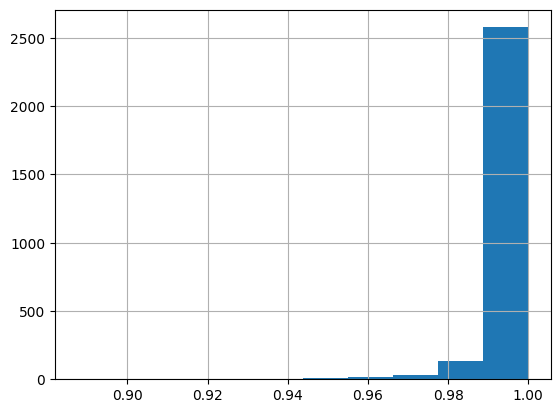

In [ ]:
df_rfmt['p_alive'].hist()

In [ ]:
df_rfmt['recommended_action'].unique()

array(['vip rewards and loyalty benefits', 'promotional marketing',
       'engagement campaigns', 'automated marketing nurture',
       'upsell and cross-sell offers'], dtype=object)

In [ ]:
# Obtaining important versions for visualization
print("numpy==", np.__version__)
print("pandas==", pd.__version__)
print("scikit-learn==", sklearn.__version__)




numpy== 2.0.2
pandas== 2.3.3
scikit-learn== 1.6.1
